# Multiphase Transient Model Demo

This notebook demonstrates the main calculation ideas from the NeqSim wiki page [Multiphase 1D Transient Pipeline Model - Implementation Recommendations](https://equinor.github.io/neqsim/wiki/multiphase_transient_model.html). The page describes a full transient multiphase architecture; this notebook turns those ideas into compact runnable examples with the current `TwoFluidPipe` implementation.

The workflow covers thermodynamic phase splitting, three-phase gas-oil-water holdup profiles, terrain-driven liquid accumulation, heat transfer, a short rate-change transient, longer 20-80 km pipeline calculations, and steady plus dynamic comparisons against the published Beggs and Brill inclined-pipe correlation as implemented in `PipeBeggsAndBrills`.

```text
three-phase wellstream -> TwoFluidPipe -> outlet stream
                         |
                         +-- pressure, temperature, holdup, velocity, flow-regime, slug statistics
```

## 1. Setup

The setup cell loads NeqSim from this workspace through `devtools/neqsim_dev_setup.py`. That makes the notebook useful for development because it reads classes from `target/classes` instead of relying on a previously installed Python package.

In [ ]:
import json
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_classes, neqsim_init

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)

TwoFluidPipe = ns.JClass("neqsim.process.equipment.pipeline.TwoFluidPipe")
PipeBeggsAndBrills = ns.JClass("neqsim.process.equipment.pipeline.PipeBeggsAndBrills")
TimeMethod = ns.JClass("neqsim.process.equipment.pipeline.twophasepipe.numerics.TimeIntegrator$Method")
JavaUUID = ns.JClass("java.util.UUID")
ThermodynamicOperations = ns.ThermodynamicOperations

NOTEBOOK_PATH = Path(globals().get(
    "__vsc_ipynb_file__",
    PROJECT_ROOT / "examples" / "notebooks" / "multiphase_transient_model_demo.ipynb",
)).resolve()
OUTPUT_DIR = PROJECT_ROOT / "output" / "multiphase_transient_model_demo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim3
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim3\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim3\src\main\resources
  3. C:\Users\ESOL\.m2\repository\com\h2database\h2\2.4.240\h2-2.4.240.jar
  4. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-api\2.26.0\log4j-api-2.26.0.jar
  5. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-core\2.26.0\log4j-core-2.26.0.jar
  6. C:\Users\ESOL\.m2\repository\com\thoughtworks\xstream\xstream\1.4.21\xstream-1.4.21.jar
  7. C:\Users\ESOL\.m2\repository\io\github\x-stream\mxparser\1.2.2\mxparser-1.2.2.jar
  8. C:\Users\ESOL\.m2\repository\xmlpull\xmlpull\1.1.3.1\xmlpull-1.1.3.1.jar
  9. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-lang3\3.20.0\commons-lang3-3.20.0.jar
  10. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-math3\3.6.1\commons-math3-3.6.1.jar
  11. C:\Users\ESOL\.m2\repository\org\ejml\ejml-all\0.45.0\ejml-all-0.45.0.jar
 


JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK
Project root: C:\Users\ESOL\Documents\GitHub\neqsim3
Outputs: C:\Users\ESOL\Documents\GitHub\neqsim3\output\multiphase_transient_model_demo


## 2. Thermodynamic Coupling

The wiki architecture updates each pipe section by flashing the local fluid state and then reading phase densities, viscosities, and phase fractions. The helper below creates a simple gas-oil-water wellstream and flashes it at inlet and cooler outlet-like conditions.

In [ ]:
def create_three_phase_fluid(temperature_C=45.0, pressure_bara=75.0):
    fluid = ns.SystemSrkCPAstatoil(273.15 + temperature_C, pressure_bara)
    composition = [
        ("methane", 0.68),
        ("ethane", 0.07),
        ("propane", 0.04),
        ("n-heptane", 0.17),
        ("water", 0.04),
    ]
    for component, amount in composition:
        fluid.addComponent(component, amount)
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    return fluid


def flash_phase_table(temperature_C, pressure_bara, label):
    fluid = create_three_phase_fluid(temperature_C, pressure_bara)
    fluid.setTemperature(temperature_C, "C")
    fluid.setPressure(pressure_bara, "bara")
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()

    rows = []
    for phase_index in range(int(fluid.getNumberOfPhases())):
        phase = fluid.getPhase(phase_index)
        rows.append({
            "condition": label,
            "temperature_C": temperature_C,
            "pressure_bara": pressure_bara,
            "phase": str(phase.getType()),
            "phase_fraction": float(fluid.getBeta(phase_index)),
            "density_kg_m3": float(phase.getDensity("kg/m3")),
            "viscosity_kg_m_s": float(phase.getViscosity("kg/msec")),
        })
    return rows


phase_rows = []
phase_rows.extend(flash_phase_table(45.0, 75.0, "inlet"))
phase_rows.extend(flash_phase_table(15.0, 55.0, "cooled lower pressure"))
phase_table = pd.DataFrame(phase_rows)
display(phase_table)

,condition,temperature_C,pressure_bara,phase,phase_fraction,density_kg_m3,viscosity_kg_m_s
0,inlet,45.0,75.0,GAS,0.6827,60.1259,1.3613e-05
1,inlet,45.0,75.0,OIL,0.2786,587.5970,1.9526e-04
2,inlet,45.0,75.0,AQUEOUS,0.0387,990.0642,5.9723e-04
3,cooled lower pressure,15.0,55.0,GAS,0.6777,47.1815,1.2159e-05
4,cooled lower pressure,15.0,55.0,OIL,0.2826,617.5567,2.6187e-04
5,cooled lower pressure,15.0,55.0,AQUEOUS,0.0397,997.7214,1.1447e-03


## 3. Build a Two-Fluid Pipe

The `TwoFluidPipe` model solves separate gas and liquid momentum equations, tracks gas-oil-water holdup, and can use terrain and slug-tracking submodels. The short profile below includes a low point and a gentle rise so the holdup response is visible without making the notebook slow.

In [ ]:
PIPE_LENGTH_M = 1500.0
PIPE_DIAMETER_M = 0.25
N_SECTIONS = 15
BASE_FLOW_KG_S = 10.0
RAMP_FLOW_KG_S = 14.0
INLET_PRESSURE_BARA = 75.0
OUTLET_PRESSURE_BARA = 55.0
INLET_TEMPERATURE_C = 45.0
SEA_TEMPERATURE_C = 4.0
HEAT_TRANSFER_COEFF_W_M2K = 6.0

x_profile = np.linspace(0.0, PIPE_LENGTH_M, N_SECTIONS)
x_normalized = np.linspace(0.0, 1.0, N_SECTIONS)
elevation_profile_m = -12.0 * np.sin(np.pi * x_normalized) + 4.0 * np.sin(3.0 * np.pi * x_normalized)

feed_fluid = create_three_phase_fluid(INLET_TEMPERATURE_C, INLET_PRESSURE_BARA)
feed = ns.Stream("wellstream feed", feed_fluid)
feed.setFlowRate(BASE_FLOW_KG_S, "kg/sec")
feed.setTemperature(INLET_TEMPERATURE_C, "C")
feed.setPressure(INLET_PRESSURE_BARA, "bara")
feed.run()

pipe = TwoFluidPipe("multiphase tieback", feed)
pipe.setLength(PIPE_LENGTH_M)
pipe.setDiameter(PIPE_DIAMETER_M)
pipe.setNumberOfSections(N_SECTIONS)
pipe.setRoughness(4.5e-5)
pipe.setElevationProfile(elevation_profile_m.tolist())
pipe.setOutletPressure(OUTLET_PRESSURE_BARA, "bara")
pipe.setSurfaceTemperature(SEA_TEMPERATURE_C, "C")
pipe.setHeatTransferCoefficient(HEAT_TRANSFER_COEFF_W_M2K)
pipe.setOLGAModelType(TwoFluidPipe.OLGAModelType.SIMPLIFIED)
pipe.setSlugTrackingMode(TwoFluidPipe.SlugTrackingMode.SIMPLIFIED)
pipe.setEnableAdaptiveTimestepping(True)
pipe.setTimeIntegrationMethod(TimeMethod.IMEX_PRESSURE_CORRECTION)

pipe.run()

print("Steady-state initialization complete")
print(f"Dominant flow regime: {pipe.getDominantFlowRegime()}")
print(f"Average liquid holdup: {pipe.getAverageLiquidHoldup():.4f}")
print(f"Liquid inventory: {pipe.getLiquidInventory('m3'):.3f} m3")

Steady-state initialization complete
Dominant flow regime: STRATIFIED_SMOOTH
Average liquid holdup: 0.4689
Liquid inventory: 31.889 m3


In [ ]:
def java_double_array(values):
    return np.array(list(values), dtype=float)


def flow_regime_names(values):
    return [str(value) if value is not None else "UNKNOWN" for value in list(values)]


def profile_dataframe(pipe_model, elevations, pipe_length_m=PIPE_LENGTH_M):
    position_m = java_double_array(pipe_model.getPositionProfile())
    n = len(position_m)
    elevation = np.interp(position_m, np.linspace(0.0, pipe_length_m, len(elevations)), elevations)
    return pd.DataFrame({
        "position_m": position_m,
        "distance_km": position_m / 1000.0,
        "elevation_m": elevation,
        "pressure_bara": java_double_array(pipe_model.getPressureProfile()) / 1.0e5,
        "temperature_C": java_double_array(pipe_model.getTemperatureProfile()) - 273.15,
        "liquid_holdup": java_double_array(pipe_model.getLiquidHoldupProfile()),
        "oil_holdup": java_double_array(pipe_model.getOilHoldupProfile()),
        "water_holdup": java_double_array(pipe_model.getWaterHoldupProfile()),
        "gas_velocity_m_s": java_double_array(pipe_model.getGasVelocityProfile()),
        "liquid_velocity_m_s": java_double_array(pipe_model.getLiquidVelocityProfile()),
        "flow_regime": flow_regime_names(pipe_model.getFlowRegimeProfile())[:n],
    })


steady_profile = profile_dataframe(pipe, elevation_profile_m)
steady_inlet_pressure_bara = float(steady_profile["pressure_bara"].iloc[0])
steady_outlet_pressure_bara = float(pipe.getOutletStream().getPressure())
summary = pd.DataFrame([
    {
        "case": "steady initialization",
        "feed_flow_kg_s": BASE_FLOW_KG_S,
        "pipe_inlet_pressure_bara": steady_inlet_pressure_bara,
        "outlet_pressure_bara": steady_outlet_pressure_bara,
        "pressure_drop_bar": steady_inlet_pressure_bara - steady_outlet_pressure_bara,
        "outlet_temperature_C": float(pipe.getOutletStream().getTemperature() - 273.15),
        "average_liquid_holdup": float(pipe.getAverageLiquidHoldup()),
        "liquid_inventory_m3": float(pipe.getLiquidInventory("m3")),
        "dominant_flow_regime": str(pipe.getDominantFlowRegime()),
    }
])
display(summary)
display(steady_profile.head())

,case,feed_flow_kg_s,pipe_inlet_pressure_bara,outlet_pressure_bara,pressure_drop_bar,outlet_temperature_C,average_liquid_holdup,liquid_inventory_m3,dominant_flow_regime
0,steady initialization,10.0,55.447,55.0,0.447,35.669,0.4689,31.8895,STRATIFIED_SMOOTH


,position_m,distance_km,elevation_m,pressure_bara,temperature_C,liquid_holdup,oil_holdup,water_holdup,gas_velocity_m_s,liquid_velocity_m_s,flow_regime
0,50.0,0.05,-0.0823,55.4470,45.0000,0.9100,0.8908,0.0192,2.1074,0.2562,STRATIFIED_SMOOTH
1,150.0,0.15,-0.6285,55.4535,44.2507,0.3761,0.3657,0.0104,2.1050,0.5552,STRATIFIED_SMOOTH
2,250.0,0.25,-2.1639,55.4659,43.5150,0.3779,0.3641,0.0138,2.0957,0.5534,STRATIFIED_SMOOTH
3,350.0,0.35,-4.8829,55.5161,42.7929,0.3800,0.3617,0.0183,2.0851,0.5514,STRATIFIED_SMOOTH
4,450.0,0.45,-8.4575,55.5986,42.0839,0.3822,0.3579,0.0243,2.0741,0.5493,STRATIFIED_SMOOTH


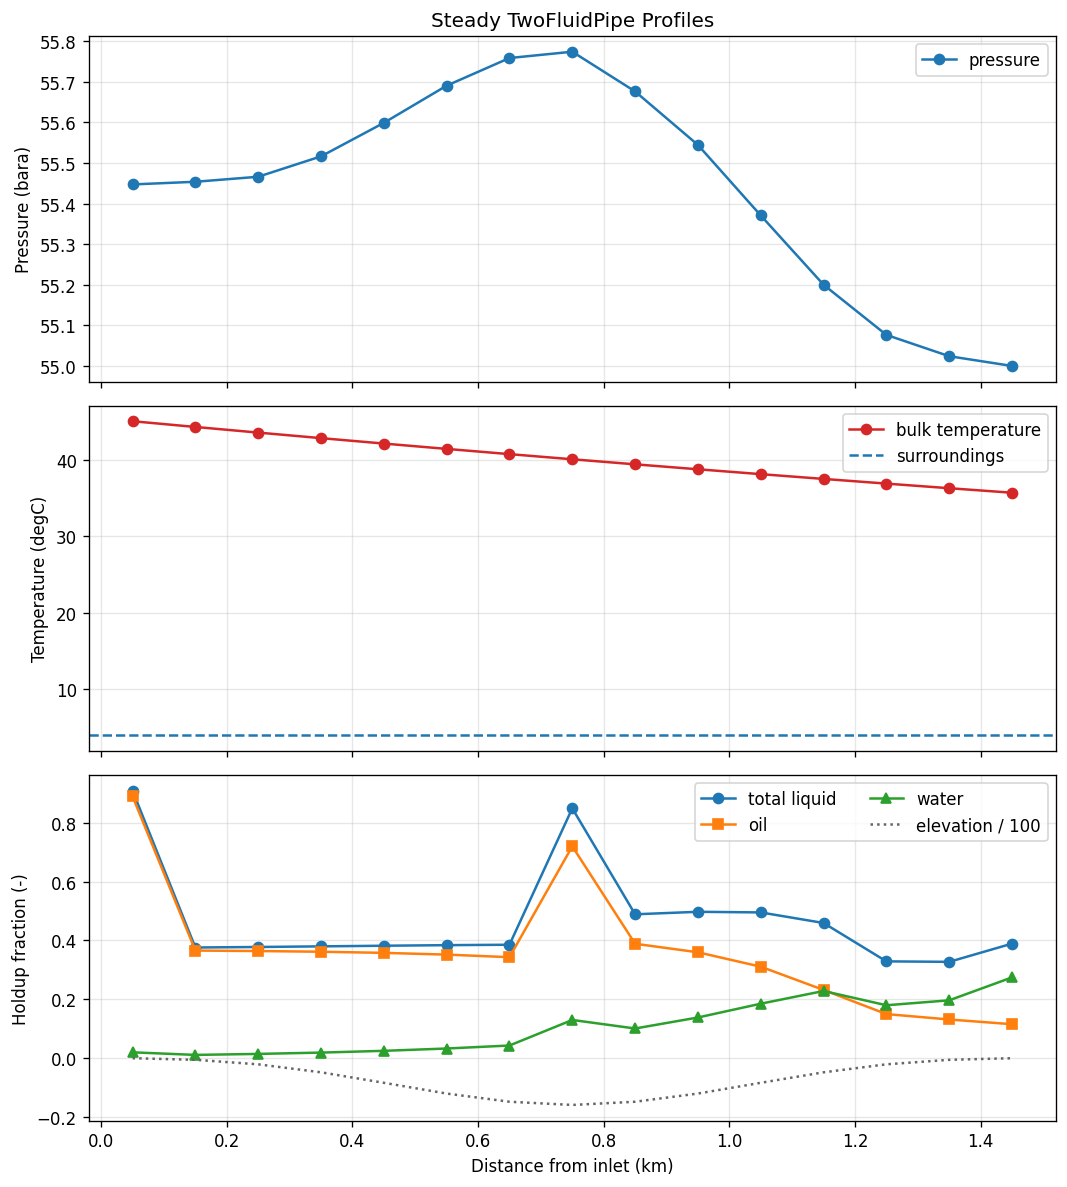

Saved C:\Users\ESOL\Documents\GitHub\neqsim3\output\multiphase_transient_model_demo\steady_profiles.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(steady_profile["distance_km"], steady_profile["pressure_bara"], marker="o", label="pressure")
axes[0].set_ylabel("Pressure (bara)")
axes[0].set_title("Steady TwoFluidPipe Profiles")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(steady_profile["distance_km"], steady_profile["temperature_C"], color="tab:red", marker="o", label="bulk temperature")
axes[1].axhline(SEA_TEMPERATURE_C, color="tab:blue", linestyle="--", label="surroundings")
axes[1].set_ylabel("Temperature (degC)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(steady_profile["distance_km"], steady_profile["liquid_holdup"], marker="o", label="total liquid")
axes[2].plot(steady_profile["distance_km"], steady_profile["oil_holdup"], marker="s", label="oil")
axes[2].plot(steady_profile["distance_km"], steady_profile["water_holdup"], marker="^", label="water")
axes[2].plot(steady_profile["distance_km"], steady_profile["elevation_m"] / 100.0, color="0.4", linestyle=":", label="elevation / 100")
axes[2].set_xlabel("Distance from inlet (km)")
axes[2].set_ylabel("Holdup fraction (-)")
axes[2].grid(True, alpha=0.3)
axes[2].legend(ncol=2)

fig.tight_layout()
figure_1 = OUTPUT_DIR / "steady_profiles.png"
fig.savefig(figure_1, bbox_inches="tight")
plt.show()
print(f"Saved {figure_1}")

### Figure 1 Discussion

Observation: the plot combines pressure, temperature, liquid holdup, and the scaled terrain profile for the initialized two-fluid calculation. The holdup curve is the key multiphase result because it shows where the model places oil and water inventory along the line.

Physical mechanism: the thermodynamic flash supplies local phase properties, while the two-fluid model balances gravity, friction, pressure gradient, and slip. Low spots and uphill sections promote liquid retention because the gas phase must carry the denser liquid uphill.

Engineering implication: liquid inventory is not just a stream property; it is spatially distributed. That matters for slug-catcher sizing, restart studies, hydrate exposure time, and pigging volumes.

Recommendation: use this type of profile check before transient studies so that the initial condition is physically plausible and the grid has enough resolution near terrain changes.

## 4. Short Rate-Change Transient

The wiki page highlights startup, shutdown, pigging, and rate changes as target transient scenarios. This compact example ramps inlet mass flow after a few steps and records the pipe response. A Java `UUID` is used because `runTransient(dt, id)` expects `java.util.UUID`, not Python's `uuid.UUID`.

In [ ]:
def capture_metrics(pipe_model, time_s, flow_kg_s):
    profile = profile_dataframe(pipe_model, elevation_profile_m)
    return {
        "time_s": float(time_s),
        "feed_flow_kg_s": float(flow_kg_s),
        "pipe_inlet_pressure_bara": float(profile["pressure_bara"].iloc[0]),
        "outlet_pressure_bara": float(pipe_model.getOutletStream().getPressure()),
        "outlet_temperature_C": float(pipe_model.getOutletStream().getTemperature() - 273.15),
        "average_liquid_holdup": float(pipe_model.getAverageLiquidHoldup()),
        "liquid_inventory_m3": float(pipe_model.getLiquidInventory("m3")),
        "outlet_slug_count": int(pipe_model.getOutletSlugCount()),
        "max_slug_length_at_outlet_m": float(pipe_model.getMaxSlugLengthAtOutlet()),
        "dominant_flow_regime": str(pipe_model.getDominantFlowRegime()),
        "adaptive_dt_factor": float(pipe_model.getAdaptiveDtFactor()),
    }


history = [capture_metrics(pipe, pipe.getSimulationTime(), BASE_FLOW_KG_S)]
profile_snapshots = {"initial": steady_profile.copy()}

run_id = JavaUUID.randomUUID()
time_step_s = 0.5
number_of_steps = 8
current_flow = BASE_FLOW_KG_S

for step in range(1, number_of_steps + 1):
    if step == 4:
        current_flow = RAMP_FLOW_KG_S
        feed.setFlowRate(current_flow, "kg/sec")
        feed.run()

    pipe.runTransient(time_step_s, run_id)
    history.append(capture_metrics(pipe, pipe.getSimulationTime(), current_flow))

    if step in (4, number_of_steps):
        profile_snapshots[f"step {step}"] = profile_dataframe(pipe, elevation_profile_m)

history_df = pd.DataFrame(history)
display(history_df)

,time_s,feed_flow_kg_s,pipe_inlet_pressure_bara,outlet_pressure_bara,outlet_temperature_C,average_liquid_holdup,liquid_inventory_m3,outlet_slug_count,max_slug_length_at_outlet_m,dominant_flow_regime,adaptive_dt_factor
0,0.0,10.0,55.4470,55.0,35.6690,0.4689,31.8895,0,0.0,STRATIFIED_SMOOTH,1.0000
1,0.5,10.0,49.5000,55.0,35.6735,0.7668,32.5722,0,0.0,SLUG,1.0000
2,1.0,10.0,62.9437,55.0,35.6751,0.7418,31.8444,0,0.0,ANNULAR,0.0198
3,1.5,10.0,65.4049,55.0,35.6698,0.7462,32.2620,0,0.0,ANNULAR,0.0454
4,2.0,14.0,71.9283,55.0,35.6617,0.7513,32.5130,0,0.0,ANNULAR,0.0273
5,2.5,14.0,71.2658,55.0,35.6564,0.7564,32.7837,0,0.0,ANNULAR,0.0210
6,3.0,14.0,64.1843,55.0,35.6526,0.7608,32.9529,0,0.0,ANNULAR,0.0458
7,3.5,14.0,58.0530,55.0,35.6500,0.7651,33.2078,0,0.0,ANNULAR,0.0783
8,4.0,14.0,56.5948,55.0,35.6478,0.7676,33.2864,0,0.0,ANNULAR,0.1156


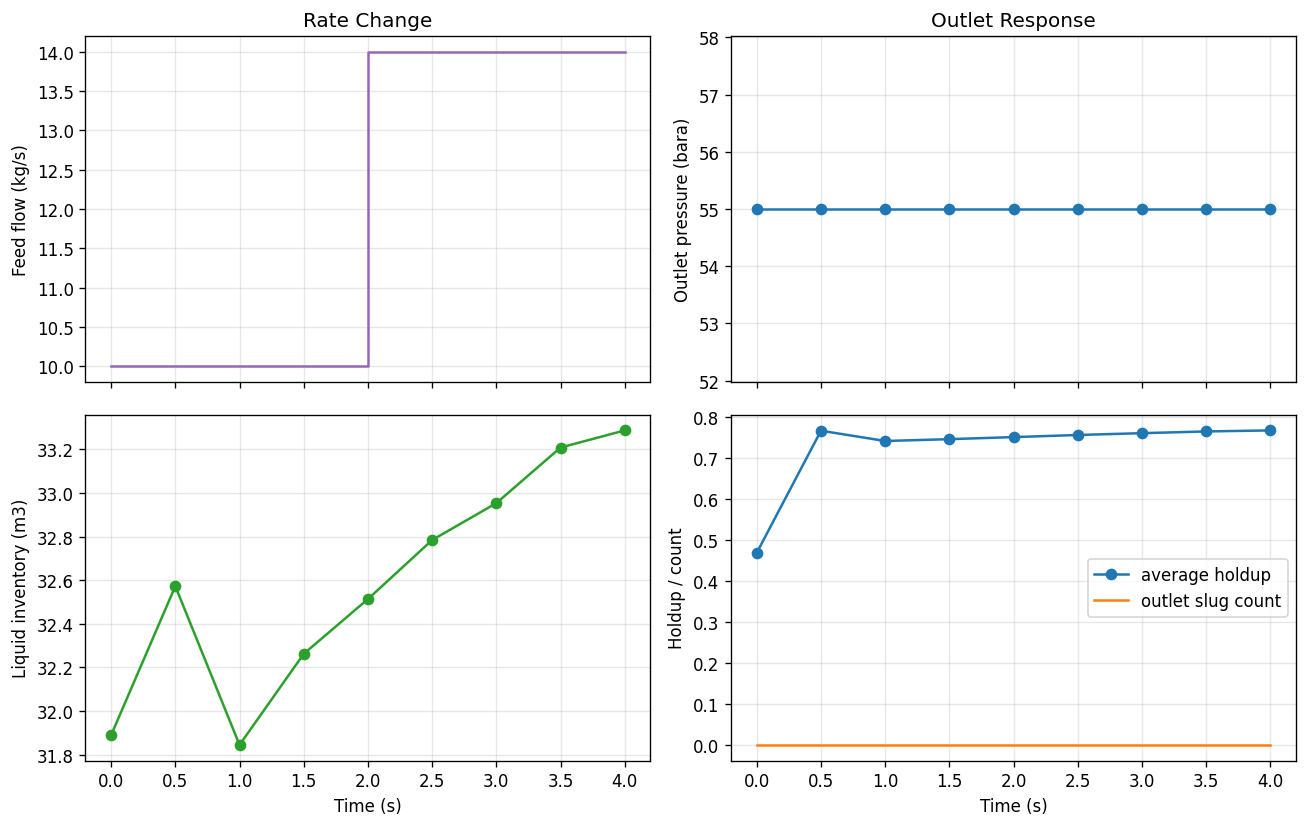

Saved C:\Users\ESOL\Documents\GitHub\neqsim3\output\multiphase_transient_model_demo\transient_rate_change.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

axes[0, 0].step(history_df["time_s"], history_df["feed_flow_kg_s"], where="post", color="tab:purple")
axes[0, 0].set_ylabel("Feed flow (kg/s)")
axes[0, 0].set_title("Rate Change")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_df["time_s"], history_df["outlet_pressure_bara"], marker="o", color="tab:blue")
axes[0, 1].set_ylabel("Outlet pressure (bara)")
axes[0, 1].set_title("Outlet Response")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history_df["time_s"], history_df["liquid_inventory_m3"], marker="o", color="tab:green")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Liquid inventory (m3)")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history_df["time_s"], history_df["average_liquid_holdup"], marker="o", label="average holdup")
axes[1, 1].step(history_df["time_s"], history_df["outlet_slug_count"], where="post", label="outlet slug count")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Holdup / count")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

fig.tight_layout()
figure_2 = OUTPUT_DIR / "transient_rate_change.png"
fig.savefig(figure_2, bbox_inches="tight")
plt.show()
print(f"Saved {figure_2}")

### Figure 2 Discussion

Observation: the transient history records how outlet pressure, average holdup, inventory, and slug statistics respond after the inlet flow increase. In this compact case the simulated time is intentionally short, so the plot is a method demonstration rather than a design-duration transient study.

Physical mechanism: a rate increase changes gas and liquid superficial velocities. The two-fluid solver advances the section states with adaptive substeps, while slug and accumulation submodels update inventory and event statistics.

Engineering implication: transient multiphase outputs should be tracked as time histories, not only final outlet conditions. Inventory and slug metrics are often the variables that drive operating limits.

Recommendation: for project studies, extend the time horizon to several residence times, refine the grid around elevation changes, and compare at least one case against field data, laboratory data, or a trusted simulator.

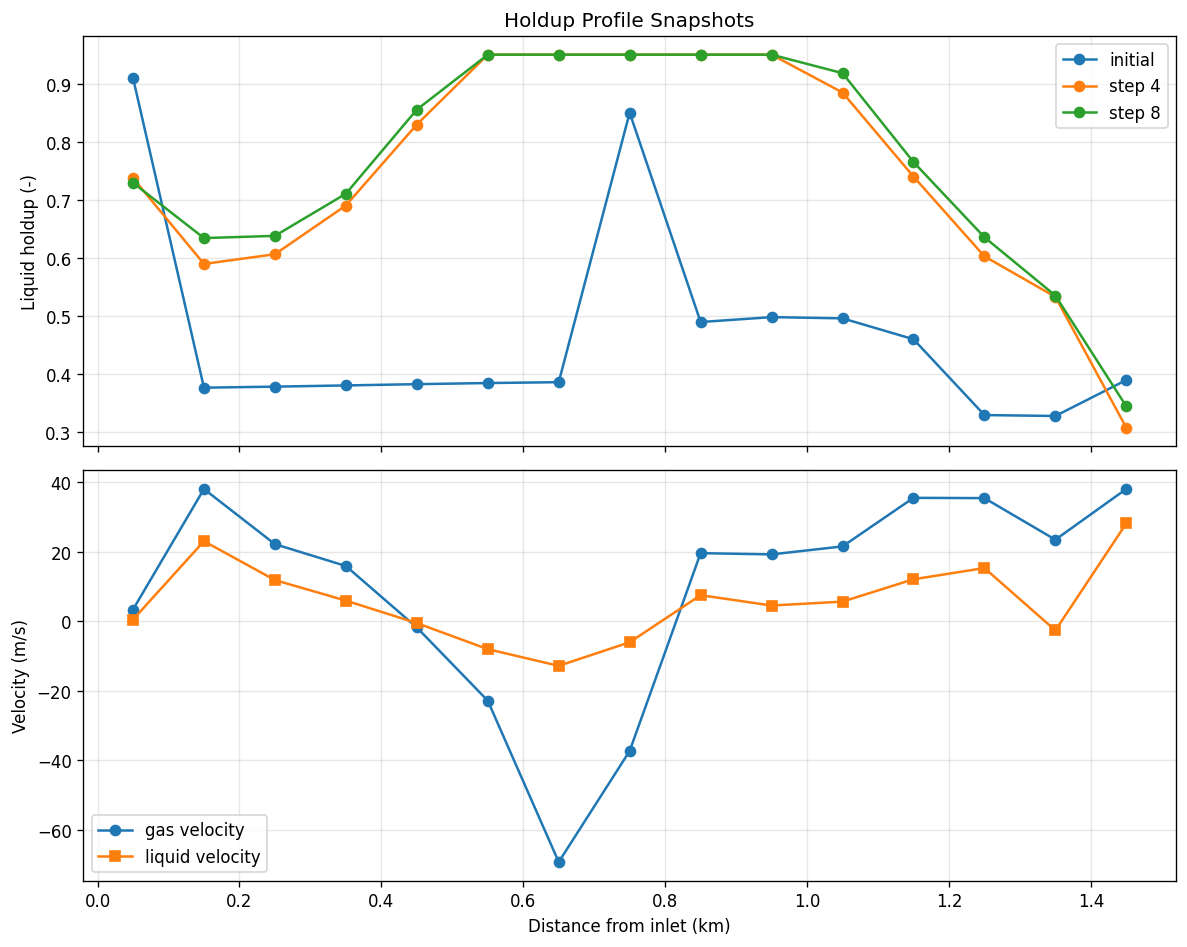

,flow_regime,section_count
0,ANNULAR,10
1,SINGLE_PHASE_LIQUID,4
2,SINGLE_PHASE_GAS,1


Saved C:\Users\ESOL\Documents\GitHub\neqsim3\output\multiphase_transient_model_demo\profile_snapshots.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for label, snapshot in profile_snapshots.items():
    axes[0].plot(snapshot["distance_km"], snapshot["liquid_holdup"], marker="o", label=label)
axes[0].set_ylabel("Liquid holdup (-)")
axes[0].set_title("Holdup Profile Snapshots")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

final_profile = profile_snapshots[f"step {number_of_steps}"]
axes[1].plot(final_profile["distance_km"], final_profile["gas_velocity_m_s"], marker="o", label="gas velocity")
axes[1].plot(final_profile["distance_km"], final_profile["liquid_velocity_m_s"], marker="s", label="liquid velocity")
axes[1].set_xlabel("Distance from inlet (km)")
axes[1].set_ylabel("Velocity (m/s)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
figure_3 = OUTPUT_DIR / "profile_snapshots.png"
fig.savefig(figure_3, bbox_inches="tight")
plt.show()

regime_counts = final_profile["flow_regime"].value_counts().rename_axis("flow_regime").reset_index(name="section_count")
display(regime_counts)
print(f"Saved {figure_3}")

### Figure 3 Discussion

Observation: profile snapshots show whether the rate change mainly shifts the entire holdup field or affects specific terrain locations. The velocity comparison shows the phase slip that motivates the two-fluid model.

Physical mechanism: gas and liquid do not generally travel at the same velocity. Slip, gravity, and flow-regime transitions change local liquid holdup even when the inlet composition is fixed.

Engineering implication: the same total feed can produce different local liquid loads depending on terrain and transient history. Local holdup peaks can be more important than the average for hydrate management or slugging checks.

Recommendation: use profile snapshots together with time histories; a single outlet pressure trend can hide internal liquid redistribution.

## 5. Long Pipeline Examples and Literature-Correlation Check

The short example is useful for learning, but multiphase flow assurance decisions are often made on long tiebacks. The next cells run 20, 50, and 80 km gas-condensate-water pipelines and compare the steady pressure drop against `PipeBeggsAndBrills`, NeqSim's implementation of the published Beggs and Brill inclined-pipe correlation.

This is a correlation comparison, not a claim that the two-fluid model should reproduce the empirical correlation exactly. `TwoFluidPipe` resolves terrain holdup and transient inventory, while Beggs and Brill is a steady empirical pressure-gradient method.

In [ ]:
LONG_PIPE_DIAMETER_M = 0.50
LONG_INLET_TEMPERATURE_C = 60.0
LONG_INLET_PRESSURE_BARA = 120.0
LONG_BASE_FLOW_KG_S = 50.0
LONG_RAMP_FLOW_KG_S = 75.0
LONG_SEA_TEMPERATURE_C = 4.0
LONG_HEAT_TRANSFER_COEFF_W_M2K = 6.0

LONG_CASES = [
    {"case": "20 km tieback", "length_m": 20_000.0, "sections": 20},
    {"case": "50 km tieback", "length_m": 50_000.0, "sections": 30},
    {"case": "80 km tieback", "length_m": 80_000.0, "sections": 40},
]


def create_long_pipeline_fluid(temperature_C=LONG_INLET_TEMPERATURE_C, pressure_bara=LONG_INLET_PRESSURE_BARA):
    fluid = ns.SystemSrkCPAstatoil(273.15 + temperature_C, pressure_bara)
    composition = [
        ("nitrogen", 1.0),
        ("CO2", 2.5),
        ("methane", 65.0),
        ("ethane", 8.0),
        ("propane", 6.0),
        ("i-butane", 2.0),
        ("n-butane", 3.0),
        ("i-pentane", 2.5),
        ("n-pentane", 3.0),
        ("n-hexane", 2.5),
        ("n-heptane", 2.0),
        ("n-octane", 1.0),
        ("water", 1.5),
    ]
    for component, amount in composition:
        fluid.addComponent(component, amount)
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    return fluid


def create_long_pipeline_stream(name, flow_kg_s=LONG_BASE_FLOW_KG_S):
    fluid = create_long_pipeline_fluid()
    stream = ns.Stream(name, fluid)
    stream.setFlowRate(flow_kg_s, "kg/sec")
    stream.setTemperature(LONG_INLET_TEMPERATURE_C, "C")
    stream.setPressure(LONG_INLET_PRESSURE_BARA, "bara")
    stream.run()
    return stream


def long_pipeline_terrain_profile(sections):
    x = np.linspace(0.0, 1.0, sections)
    return (
        -80.0 * np.exp(-((x - 0.15) / 0.06) ** 2)
        + 60.0 * np.exp(-((x - 0.30) / 0.05) ** 2)
        - 120.0 * np.exp(-((x - 0.45) / 0.08) ** 2)
        + 50.0 * np.exp(-((x - 0.60) / 0.05) ** 2)
        - 70.0 * np.exp(-((x - 0.75) / 0.06) ** 2)
        + 40.0 * np.exp(-((x - 0.90) / 0.05) ** 2)
    )


def configure_twofluid_long_pipe(case, feed_stream, terrain):
    pipe_model = TwoFluidPipe(case["case"] + " TwoFluidPipe", feed_stream)
    pipe_model.setLength(case["length_m"])
    pipe_model.setDiameter(LONG_PIPE_DIAMETER_M)
    pipe_model.setNumberOfSections(case["sections"])
    pipe_model.setRoughness(4.5e-5)
    pipe_model.setElevationProfile(terrain.tolist())
    pipe_model.setSurfaceTemperature(LONG_SEA_TEMPERATURE_C, "C")
    pipe_model.setHeatTransferCoefficient(LONG_HEAT_TRANSFER_COEFF_W_M2K)
    pipe_model.setThermodynamicUpdateInterval(100)
    pipe_model.setOLGAModelType(TwoFluidPipe.OLGAModelType.SIMPLIFIED)
    pipe_model.setSlugTrackingMode(TwoFluidPipe.SlugTrackingMode.SIMPLIFIED)
    pipe_model.setEnableAdaptiveTimestepping(True)
    pipe_model.setAdaptiveMaxPressureChangeRatio(1.5)
    pipe_model.setTimeIntegrationMethod(TimeMethod.IMEX_PRESSURE_CORRECTION)
    return pipe_model


def run_beggs_brill_reference(case):
    reference_feed = create_long_pipeline_stream(case["case"] + " Beggs-Brill feed")
    reference_pipe = PipeBeggsAndBrills(case["case"] + " Beggs-Brill", reference_feed)
    reference_pipe.setLength(case["length_m"])
    reference_pipe.setDiameter(LONG_PIPE_DIAMETER_M)
    reference_pipe.setElevation(0.0)
    reference_pipe.setPipeWallRoughness(4.5e-5)
    reference_pipe.setNumberOfIncrements(case["sections"])
    reference_pipe.setConstantSurfaceTemperature(LONG_SEA_TEMPERATURE_C, "C")
    reference_pipe.setHeatTransferCoefficient(LONG_HEAT_TRANSFER_COEFF_W_M2K)
    reference_pipe.run()
    pressure_profile = java_double_array(reference_pipe.getPressureProfile())
    temperature_profile = java_double_array(reference_pipe.getTemperatureProfile())
    liquid_holdup_profile = java_double_array(reference_pipe.getLiquidHoldupProfile())
    return {
        "pressure_drop_bar": float(reference_pipe.getPressureDrop()),
        "outlet_pressure_bara": float(reference_pipe.getOutletStream().getPressure("bara")),
        "outlet_temperature_C": float(reference_pipe.getOutletStream().getTemperature("C")),
        "average_liquid_holdup": float(np.mean(liquid_holdup_profile)) if len(liquid_holdup_profile) else np.nan,
        "pressure_profile_bara": pressure_profile,
        "temperature_profile_C": temperature_profile - 273.15 if len(temperature_profile) else temperature_profile,
        "status": "ok",
    }


long_case_rows = []
long_profiles = {}
long_terrains = {}

for case in LONG_CASES:
    terrain = long_pipeline_terrain_profile(case["sections"])
    feed_stream = create_long_pipeline_stream(case["case"] + " feed")
    twofluid_pipe = configure_twofluid_long_pipe(case, feed_stream, terrain)
    twofluid_pipe.run()
    twofluid_profile = profile_dataframe(twofluid_pipe, terrain, case["length_m"])
    long_profiles[case["case"]] = twofluid_profile
    long_terrains[case["case"]] = terrain

    twofluid_pressure_drop = float(twofluid_profile["pressure_bara"].iloc[0] - twofluid_profile["pressure_bara"].iloc[-1])
    try:
        bb = run_beggs_brill_reference(case)
    except Exception as exc:
        bb = {
            "pressure_drop_bar": np.nan,
            "outlet_pressure_bara": np.nan,
            "outlet_temperature_C": np.nan,
            "average_liquid_holdup": np.nan,
            "pressure_profile_bara": np.array([]),
            "temperature_profile_C": np.array([]),
            "status": str(exc),
        }

    deviation_pct = (
        abs(twofluid_pressure_drop - bb["pressure_drop_bar"]) / max(abs(bb["pressure_drop_bar"]), 1.0e-12) * 100.0
        if np.isfinite(bb["pressure_drop_bar"])
        else np.nan
    )
    long_case_rows.append({
        "case": case["case"],
        "length_km": case["length_m"] / 1000.0,
        "sections": case["sections"],
        "flow_kg_s": LONG_BASE_FLOW_KG_S,
        "twofluid_pressure_drop_bar": twofluid_pressure_drop,
        "beggs_brill_pressure_drop_bar": bb["pressure_drop_bar"],
        "pressure_drop_deviation_pct": deviation_pct,
        "twofluid_outlet_pressure_bara": float(twofluid_profile["pressure_bara"].iloc[-1]),
        "beggs_brill_outlet_pressure_bara": bb["outlet_pressure_bara"],
        "twofluid_outlet_temperature_C": float(twofluid_profile["temperature_C"].iloc[-1]),
        "beggs_brill_outlet_temperature_C": bb["outlet_temperature_C"],
        "twofluid_average_liquid_holdup": float(twofluid_profile["liquid_holdup"].mean()),
        "beggs_brill_average_liquid_holdup": bb["average_liquid_holdup"],
        "twofluid_liquid_inventory_m3": float(twofluid_pipe.getLiquidInventory("m3")),
        "twofluid_dominant_flow_regime": str(twofluid_pipe.getDominantFlowRegime()),
        "beggs_brill_status": bb["status"],
    })

long_case_results = pd.DataFrame(long_case_rows)
long_case_results.to_csv(OUTPUT_DIR / "long_pipeline_comparison.csv", index=False)
display(long_case_results)

,case,length_km,sections,flow_kg_s,twofluid_pressure_drop_bar,beggs_brill_pressure_drop_bar,pressure_drop_deviation_pct,twofluid_outlet_pressure_bara,beggs_brill_outlet_pressure_bara,twofluid_outlet_temperature_C,beggs_brill_outlet_temperature_C,twofluid_average_liquid_holdup,beggs_brill_average_liquid_holdup,twofluid_liquid_inventory_m3,twofluid_dominant_flow_regime,beggs_brill_status
0,20 km tieback,20.0,20,50.0,1.1700,0.9026,29.6324,118.8300,119.0974,21.0961,22.4676,0.6544,0.5126,2473.2189,STRATIFIED_WAVY,ok
1,50 km tieback,50.0,30,50.0,2.0658,2.0145,2.5455,117.9342,117.9855,6.7375,7.4747,0.7463,0.5807,7165.3434,SLUG,ok
2,80 km tieback,80.0,40,50.0,3.3096,3.0582,8.2189,116.6904,116.9418,4.4293,4.5828,0.8022,0.6123,12407.4527,SLUG,ok


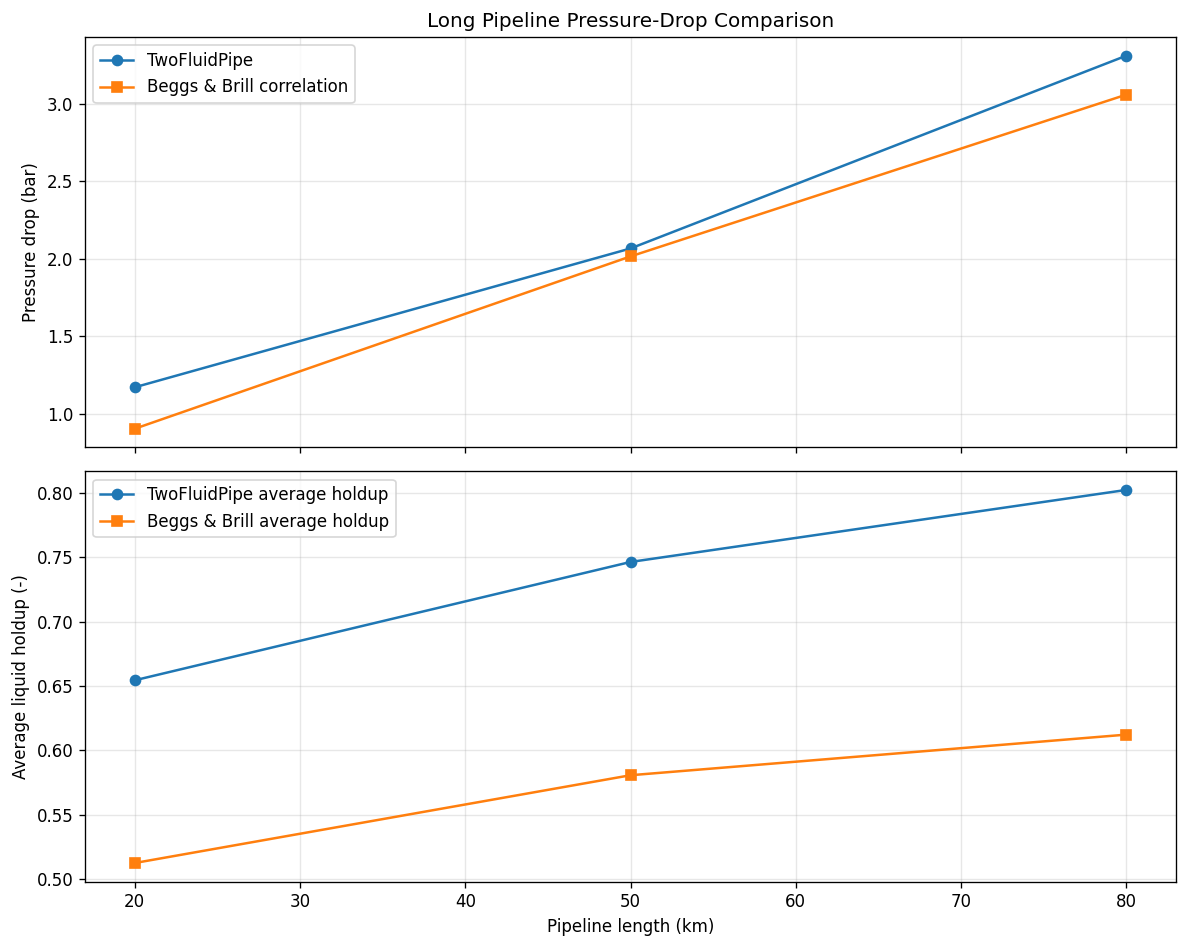

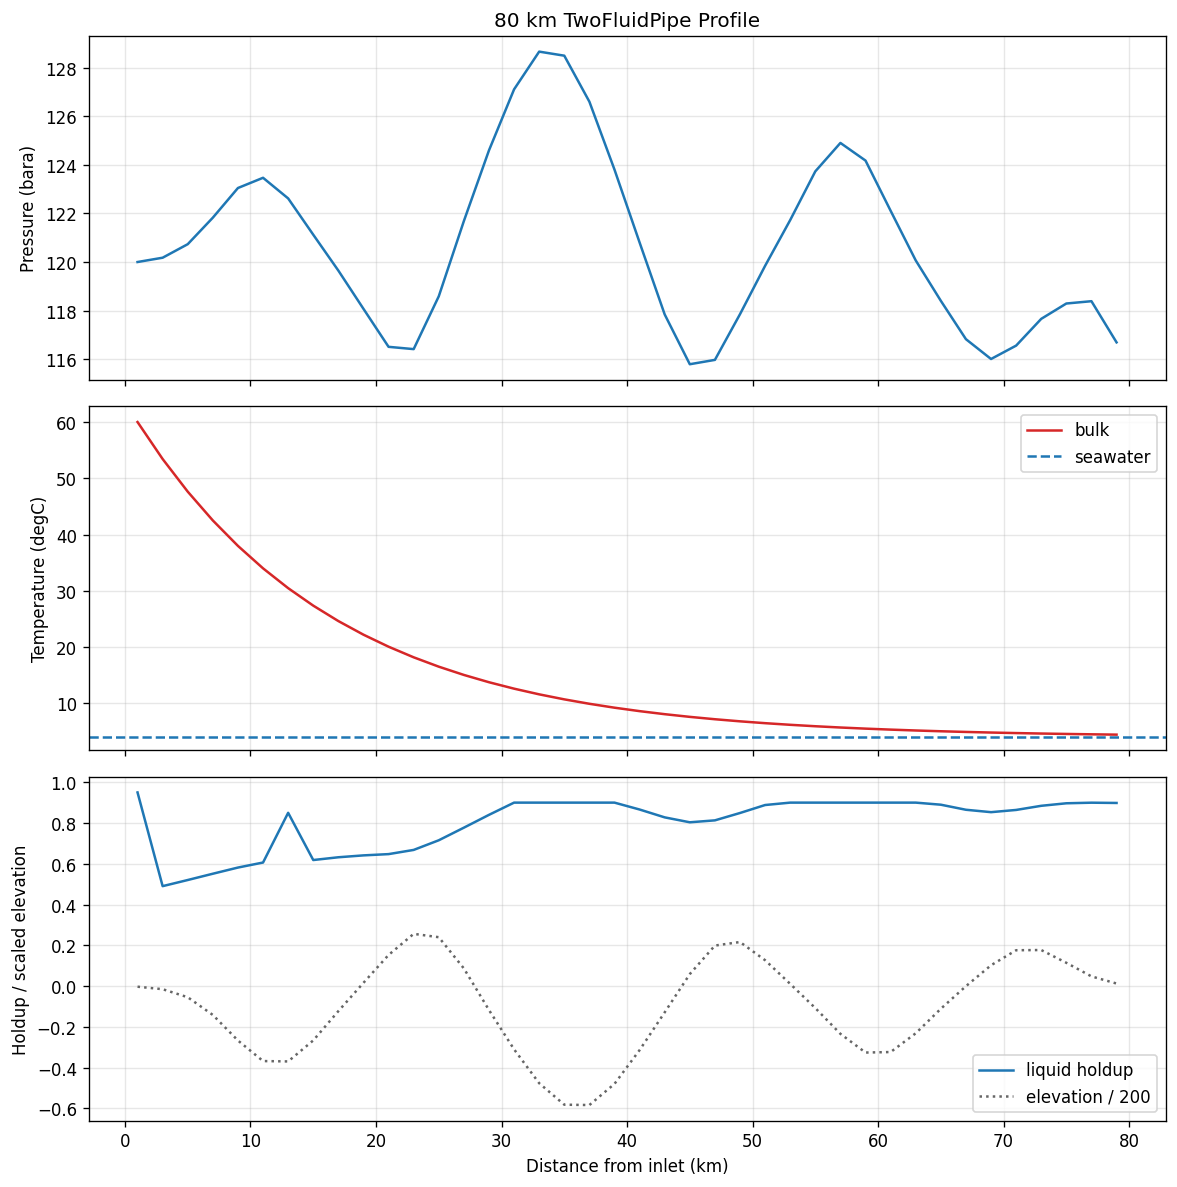

Saved C:\Users\ESOL\Documents\GitHub\neqsim3\output\multiphase_transient_model_demo\long_pipeline_beggs_brill_comparison.png
Saved C:\Users\ESOL\Documents\GitHub\neqsim3\output\multiphase_transient_model_demo\long_pipeline_80km_profile.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(
    long_case_results["length_km"],
    long_case_results["twofluid_pressure_drop_bar"],
    marker="o",
    label="TwoFluidPipe",
)
axes[0].plot(
    long_case_results["length_km"],
    long_case_results["beggs_brill_pressure_drop_bar"],
    marker="s",
    label="Beggs & Brill correlation",
)
axes[0].set_ylabel("Pressure drop (bar)")
axes[0].set_title("Long Pipeline Pressure-Drop Comparison")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(
    long_case_results["length_km"],
    long_case_results["twofluid_average_liquid_holdup"],
    marker="o",
    label="TwoFluidPipe average holdup",
)
axes[1].plot(
    long_case_results["length_km"],
    long_case_results["beggs_brill_average_liquid_holdup"],
    marker="s",
    label="Beggs & Brill average holdup",
)
axes[1].set_xlabel("Pipeline length (km)")
axes[1].set_ylabel("Average liquid holdup (-)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
figure_4 = OUTPUT_DIR / "long_pipeline_beggs_brill_comparison.png"
fig.savefig(figure_4, bbox_inches="tight")
plt.show()

profile_80km = long_profiles["80 km tieback"]
terrain_80km = long_terrains["80 km tieback"]
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(profile_80km["distance_km"], profile_80km["pressure_bara"], color="tab:blue")
axes[0].set_ylabel("Pressure (bara)")
axes[0].set_title("80 km TwoFluidPipe Profile")
axes[0].grid(True, alpha=0.3)

axes[1].plot(profile_80km["distance_km"], profile_80km["temperature_C"], color="tab:red", label="bulk")
axes[1].axhline(LONG_SEA_TEMPERATURE_C, color="tab:blue", linestyle="--", label="seawater")
axes[1].set_ylabel("Temperature (degC)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(profile_80km["distance_km"], profile_80km["liquid_holdup"], label="liquid holdup")
axes[2].plot(profile_80km["distance_km"], profile_80km["elevation_m"] / 200.0, color="0.4", linestyle=":", label="elevation / 200")
axes[2].set_xlabel("Distance from inlet (km)")
axes[2].set_ylabel("Holdup / scaled elevation")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

fig.tight_layout()
figure_5 = OUTPUT_DIR / "long_pipeline_80km_profile.png"
fig.savefig(figure_5, bbox_inches="tight")
plt.show()
print(f"Saved {figure_4}")
print(f"Saved {figure_5}")

### Figures 4 and 5 Discussion

Observation: the pressure-drop comparison shows whether the mechanistic two-fluid result stays in the same engineering range as the Beggs and Brill published correlation as the line grows from 20 to 80 km. The 80 km profile then shows where pressure, cooldown, and liquid holdup sit along the undulating tieback.

Physical mechanism: pressure drop scales with length, flow velocity, phase split, density, and liquid holdup. Beggs and Brill captures this with empirical inclined-pipe pressure-gradient factors; the two-fluid model reconstructs section states from phase momentum, terrain, slip, and local thermodynamics.

Engineering implication: agreement within a broad range is a useful screening check, while differences are expected when terrain liquid storage becomes important. Large deviations should trigger comparison against measured field data, OLGA/LedaFlow, or raw laboratory datasets for the specific fluid and inclination range.

Recommendation: use the Beggs and Brill line as a quick literature-correlation benchmark, then use the two-fluid profiles to inspect local holdup and transient inventory that a steady pressure-gradient correlation cannot expose.

In [ ]:
dynamic_case = LONG_CASES[-1]
# PipeBeggsAndBrills accepts a single net elevation rather than a full terrain profile.
# Use matched flat geometry for the dynamic correlation comparison, while the steady
# long-pipeline cases above keep the undulating terrain robustness check.
dynamic_terrain = np.zeros(dynamic_case["sections"])
dynamic_terrain_note = "Matched flat/equivalent-elevation geometry for Beggs-Brill dynamic comparison"
dynamic_feed = create_long_pipeline_stream("80 km dynamic feed", LONG_BASE_FLOW_KG_S)
dynamic_pipe = configure_twofluid_long_pipe(dynamic_case, dynamic_feed, dynamic_terrain)
dynamic_pipe.useInletPressureDrivenTransient()
dynamic_pipe.run()

LONG_DYNAMIC_WARMUP_TIME_S = 60.0
LONG_DYNAMIC_WARMUP_STEP_S = 60.0
dynamic_pipe.initializeTransientFromSteadyState(
    LONG_DYNAMIC_WARMUP_TIME_S,
    LONG_DYNAMIC_WARMUP_STEP_S,
    JavaUUID.randomUUID(),
)
dynamic_warmup_note = (
    "TwoFluidPipe is warmed from steady state before dynamic reporting so the first plotted "
    "point is not the steady-to-transient relaxation step."
)

beggs_brill_dynamic_feed = create_long_pipeline_stream("80 km dynamic Beggs-Brill feed", LONG_BASE_FLOW_KG_S)
beggs_brill_dynamic_pipe = PipeBeggsAndBrills("80 km dynamic Beggs-Brill", beggs_brill_dynamic_feed)
beggs_brill_dynamic_pipe.setLength(dynamic_case["length_m"])
beggs_brill_dynamic_pipe.setDiameter(LONG_PIPE_DIAMETER_M)
beggs_brill_dynamic_pipe.setElevation(0.0)
beggs_brill_dynamic_pipe.setPipeWallRoughness(4.5e-5)
beggs_brill_dynamic_pipe.setNumberOfIncrements(dynamic_case["sections"])
beggs_brill_dynamic_pipe.setConstantSurfaceTemperature(LONG_SEA_TEMPERATURE_C, "C")
beggs_brill_dynamic_pipe.setHeatTransferCoefficient(LONG_HEAT_TRANSFER_COEFF_W_M2K)
beggs_brill_dynamic_pipe.run()
beggs_brill_dynamic_pipe.setCalculateSteadyState(False)


def capture_long_dynamic(pipe_model, time_s, flow_kg_s):
    profile = profile_dataframe(pipe_model, dynamic_terrain, dynamic_case["length_m"])
    signed_pressure_drop_bar = float(pipe_model.getSignedPressureDrop("bar"))
    pressure_drop_valid = bool(
        (not pipe_model.hasPressureRiseAcrossPipe())
        and (not pipe_model.hasBoundaryConditionPressureMismatch())
    )
    return {
        "time_s": float(time_s),
        "time_min": float(time_s / 60.0),
        "feed_flow_kg_s": float(flow_kg_s),
        "inlet_pressure_bara": float(profile["pressure_bara"].iloc[0]),
        "outlet_pressure_bara": float(pipe_model.getOutletStream().getPressure("bara")),
        "twofluid_signed_pressure_drop_bar": signed_pressure_drop_bar,
        "twofluid_pressure_drop_valid": pressure_drop_valid,
        "twofluid_inlet_pressure_residual_bar": float(pipe_model.getInletPressureResidual("bar")),
        "twofluid_boundary_residual_bar": float(pipe_model.getBoundaryConditionResidual("bar")),
        "twofluid_boundary_diagnostic": str(pipe_model.getBoundaryConditionDiagnosticMessage()),
        "average_liquid_holdup": float(pipe_model.getAverageLiquidHoldup()),
        "liquid_inventory_m3": float(pipe_model.getLiquidInventory("m3")),
        "max_liquid_holdup": float(profile["liquid_holdup"].max()),
        "max_abs_gas_velocity_m_s": float(np.abs(profile["gas_velocity_m_s"]).max()),
        "max_abs_liquid_velocity_m_s": float(np.abs(profile["liquid_velocity_m_s"]).max()),
        "adaptive_dt_factor": float(pipe_model.getAdaptiveDtFactor()),
        "dominant_flow_regime": str(pipe_model.getDominantFlowRegime()),
        "pressure_reference": str(pipe_model.getTransientPressureReference()),
        "transient_initialized_from_steady_state": bool(pipe_model.isTransientInitializedFromSteadyState()),
        "transient_warmup_duration_s": float(pipe_model.getLastTransientWarmupDuration()),
        "transient_warmup_steps": int(pipe_model.getLastTransientWarmupSteps()),
    }


def capture_beggs_brill_dynamic(pipe_model, time_s, flow_kg_s):
    pressure_profile = java_double_array(pipe_model.getPressureProfile())
    liquid_holdup_profile = java_double_array(pipe_model.getLiquidHoldupProfile())
    return {
        "time_s": float(time_s),
        "time_min": float(time_s / 60.0),
        "feed_flow_kg_s": float(flow_kg_s),
        "beggs_brill_inlet_pressure_bara": float(pressure_profile[0]) if len(pressure_profile) else np.nan,
        "beggs_brill_outlet_pressure_bara": float(pipe_model.getOutletStream().getPressure("bara")),
        "beggs_brill_pressure_drop_bar": float(pipe_model.getPressureDrop()),
        "beggs_brill_average_liquid_holdup": float(np.mean(liquid_holdup_profile)) if len(liquid_holdup_profile) else np.nan,
        "beggs_brill_outlet_temperature_C": float(pipe_model.getOutletStream().getTemperature("C")),
    }

long_dynamic_history = [capture_long_dynamic(dynamic_pipe, dynamic_pipe.getSimulationTime(), LONG_BASE_FLOW_KG_S)]
beggs_brill_dynamic_history = [capture_beggs_brill_dynamic(beggs_brill_dynamic_pipe, 0.0, LONG_BASE_FLOW_KG_S)]
long_dynamic_snapshots = {"warmed initial": profile_dataframe(dynamic_pipe, dynamic_terrain, dynamic_case["length_m"])}

run_id = JavaUUID.randomUUID()
beggs_brill_run_id = JavaUUID.randomUUID()
long_time_step_s = 300.0
current_long_flow = LONG_BASE_FLOW_KG_S

for step in range(1, 7):
    if step == 3:
        current_long_flow = LONG_RAMP_FLOW_KG_S
        dynamic_feed.setFlowRate(current_long_flow, "kg/sec")
        dynamic_feed.run()
        beggs_brill_dynamic_feed.setFlowRate(current_long_flow, "kg/sec")
        beggs_brill_dynamic_feed.run()

    dynamic_pipe.runTransient(long_time_step_s, run_id)
    beggs_brill_dynamic_pipe.runTransient(long_time_step_s, beggs_brill_run_id)
    long_dynamic_history.append(capture_long_dynamic(dynamic_pipe, dynamic_pipe.getSimulationTime(), current_long_flow))
    beggs_brill_dynamic_history.append(
        capture_beggs_brill_dynamic(beggs_brill_dynamic_pipe, dynamic_pipe.getSimulationTime(), current_long_flow)
    )

    if step in (3, 6):
        long_dynamic_snapshots[f"step {step}"] = profile_dataframe(dynamic_pipe, dynamic_terrain, dynamic_case["length_m"])

long_dynamic_df = pd.DataFrame(long_dynamic_history)
beggs_brill_dynamic_df = pd.DataFrame(beggs_brill_dynamic_history)
long_dynamic_comparison_df = long_dynamic_df.merge(
    beggs_brill_dynamic_df,
    on=["time_s", "time_min", "feed_flow_kg_s"],
    how="left",
)
long_dynamic_comparison_df["twofluid_pressure_drop_bar"] = np.where(
    long_dynamic_comparison_df["twofluid_pressure_drop_valid"],
    long_dynamic_comparison_df["twofluid_signed_pressure_drop_bar"],
    np.nan,
)
long_dynamic_comparison_df["dynamic_pressure_drop_deviation_pct"] = np.where(
    long_dynamic_comparison_df["twofluid_pressure_drop_valid"],
    np.abs(long_dynamic_comparison_df["twofluid_pressure_drop_bar"] - long_dynamic_comparison_df["beggs_brill_pressure_drop_bar"])
    / np.maximum(np.abs(long_dynamic_comparison_df["beggs_brill_pressure_drop_bar"]), 1.0e-12)
    * 100.0,
    np.nan,
)
long_dynamic_comparison_df["outlet_pressure_difference_bar"] = (
    long_dynamic_comparison_df["outlet_pressure_bara"] - long_dynamic_comparison_df["beggs_brill_outlet_pressure_bara"]
)
long_dynamic_comparison_df["average_holdup_difference"] = (
    long_dynamic_comparison_df["average_liquid_holdup"] - long_dynamic_comparison_df["beggs_brill_average_liquid_holdup"]
)

long_dynamic_df.to_csv(OUTPUT_DIR / "long_pipeline_dynamic_history.csv", index=False)
beggs_brill_dynamic_df.to_csv(OUTPUT_DIR / "long_pipeline_beggs_brill_dynamic_history.csv", index=False)
long_dynamic_comparison_df.to_csv(OUTPUT_DIR / "long_pipeline_dynamic_beggs_brill_comparison.csv", index=False)

print(dynamic_warmup_note)
display(long_dynamic_df)
display(long_dynamic_comparison_df[[
    "time_min",
    "feed_flow_kg_s",
    "twofluid_pressure_drop_bar",
    "beggs_brill_pressure_drop_bar",
    "dynamic_pressure_drop_deviation_pct",
    "outlet_pressure_difference_bar",
    "average_holdup_difference",
    "twofluid_pressure_drop_valid",
    "twofluid_inlet_pressure_residual_bar",
]])

TwoFluidPipe is warmed from steady state before dynamic reporting so the first plotted point is not the steady-to-transient relaxation step.


,time_s,time_min,feed_flow_kg_s,inlet_pressure_bara,outlet_pressure_bara,twofluid_signed_pressure_drop_bar,twofluid_pressure_drop_valid,twofluid_inlet_pressure_residual_bar,twofluid_boundary_residual_bar,twofluid_boundary_diagnostic,...,liquid_inventory_m3,max_liquid_holdup,max_abs_gas_velocity_m_s,max_abs_liquid_velocity_m_s,adaptive_dt_factor,dominant_flow_regime,pressure_reference,transient_initialized_from_steady_state,transient_warmup_duration_s,transient_warmup_steps
0,0.0,0.0,50.0,120.0,114.4256,5.5744,True,0.0,0.0,,...,11700.9757,0.5511,3.7297,27.6665,0.01,SINGLE_PHASE_GAS,INLET_PRESSURE,True,60.0,1
1,300.0,5.0,50.0,120.0,114.4267,5.5733,True,0.0,0.0,,...,11697.8701,0.5511,3.7297,27.6665,0.01,SINGLE_PHASE_GAS,INLET_PRESSURE,True,60.0,1
2,600.0,10.0,50.0,120.0,114.4275,5.5725,True,0.0,0.0,,...,11695.4766,0.5511,3.7297,27.6665,0.01,SINGLE_PHASE_GAS,INLET_PRESSURE,True,60.0,1
3,900.0,15.0,75.0,120.0,114.3226,5.6774,True,0.0,0.0,,...,11693.6067,0.5511,3.7297,27.6665,0.01,SINGLE_PHASE_GAS,INLET_PRESSURE,True,60.0,1
4,1200.0,20.0,75.0,120.0,114.3238,5.6762,True,0.0,0.0,,...,11692.1303,0.5511,3.7297,27.6665,0.01,SINGLE_PHASE_GAS,INLET_PRESSURE,True,60.0,1
5,1500.0,25.0,75.0,120.0,114.3247,5.6753,True,0.0,0.0,,...,11690.9549,0.5511,3.7297,27.6665,0.01,SINGLE_PHASE_GAS,INLET_PRESSURE,True,60.0,1
6,1800.0,30.0,75.0,120.0,114.3255,5.6745,True,0.0,0.0,,...,11690.0128,0.5511,3.7297,27.6665,0.01,SINGLE_PHASE_GAS,INLET_PRESSURE,True,60.0,1


,time_min,feed_flow_kg_s,twofluid_pressure_drop_bar,beggs_brill_pressure_drop_bar,dynamic_pressure_drop_deviation_pct,outlet_pressure_difference_bar,average_holdup_difference,twofluid_pressure_drop_valid,twofluid_inlet_pressure_residual_bar
0,0.0,50.0,5.5744,3.0582,82.2755,-2.5162,-0.1143,True,0.0
1,5.0,50.0,5.5733,3.0555,82.3994,-2.5177,-0.1144,True,0.0
2,10.0,50.0,5.5725,3.0527,82.5442,-2.5198,-0.1145,True,0.0
3,15.0,75.0,5.6774,3.0496,86.1691,-2.6278,-0.1146,True,0.0
4,20.0,75.0,5.6762,3.0463,86.3322,-2.6299,-0.1147,True,0.0
5,25.0,75.0,5.6753,3.0428,86.5153,-2.6325,-0.1148,True,0.0
6,30.0,75.0,5.6745,3.0391,86.7158,-2.6354,-0.1148,True,0.0


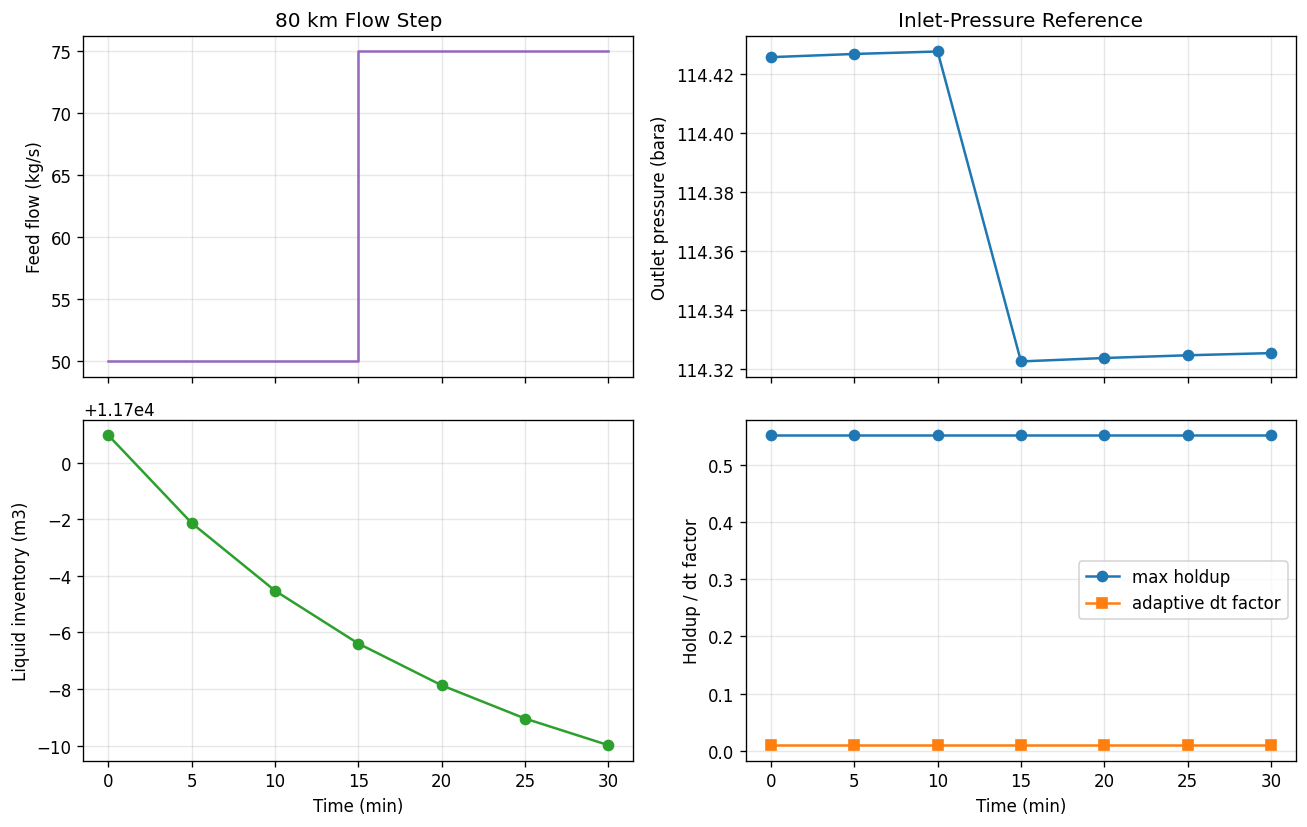

Saved C:\Users\ESOL\Documents\GitHub\neqsim3\output\multiphase_transient_model_demo\long_pipeline_dynamic_response.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

axes[0, 0].step(long_dynamic_df["time_min"], long_dynamic_df["feed_flow_kg_s"], where="post", color="tab:purple")
axes[0, 0].set_ylabel("Feed flow (kg/s)")
axes[0, 0].set_title("80 km Flow Step")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(long_dynamic_df["time_min"], long_dynamic_df["outlet_pressure_bara"], marker="o", color="tab:blue")
axes[0, 1].set_ylabel("Outlet pressure (bara)")
axes[0, 1].set_title("Inlet-Pressure Reference")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(long_dynamic_df["time_min"], long_dynamic_df["liquid_inventory_m3"], marker="o", color="tab:green")
axes[1, 0].set_xlabel("Time (min)")
axes[1, 0].set_ylabel("Liquid inventory (m3)")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(long_dynamic_df["time_min"], long_dynamic_df["max_liquid_holdup"], marker="o", label="max holdup")
axes[1, 1].plot(long_dynamic_df["time_min"], long_dynamic_df["adaptive_dt_factor"], marker="s", label="adaptive dt factor")
axes[1, 1].set_xlabel("Time (min)")
axes[1, 1].set_ylabel("Holdup / dt factor")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

fig.tight_layout()
figure_6 = OUTPUT_DIR / "long_pipeline_dynamic_response.png"
fig.savefig(figure_6, bbox_inches="tight")
plt.show()
print(f"Saved {figure_6}")

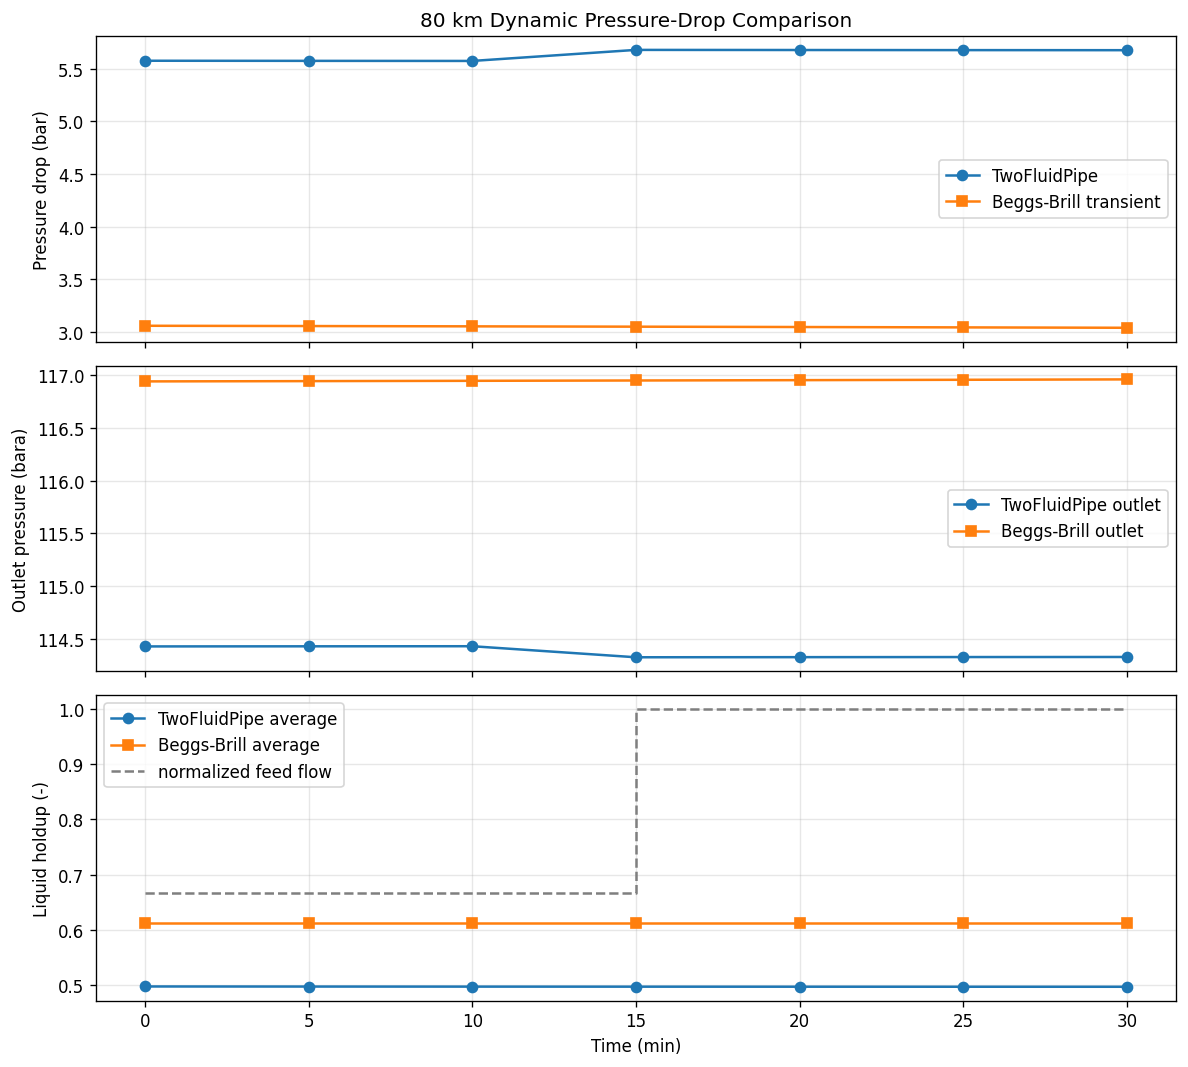

Saved C:\Users\ESOL\Documents\GitHub\neqsim3\output\multiphase_transient_model_demo\long_pipeline_dynamic_beggs_brill_comparison.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(
    long_dynamic_comparison_df["time_min"],
    long_dynamic_comparison_df["twofluid_pressure_drop_bar"],
    marker="o",
    label="TwoFluidPipe",
)
axes[0].plot(
    long_dynamic_comparison_df["time_min"],
    long_dynamic_comparison_df["beggs_brill_pressure_drop_bar"],
    marker="s",
    label="Beggs-Brill transient",
)
axes[0].set_ylabel("Pressure drop (bar)")
axes[0].set_title("80 km Dynamic Pressure-Drop Comparison")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(
    long_dynamic_comparison_df["time_min"],
    long_dynamic_comparison_df["outlet_pressure_bara"],
    marker="o",
    label="TwoFluidPipe outlet",
)
axes[1].plot(
    long_dynamic_comparison_df["time_min"],
    long_dynamic_comparison_df["beggs_brill_outlet_pressure_bara"],
    marker="s",
    label="Beggs-Brill outlet",
)
axes[1].set_ylabel("Outlet pressure (bara)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(
    long_dynamic_comparison_df["time_min"],
    long_dynamic_comparison_df["average_liquid_holdup"],
    marker="o",
    label="TwoFluidPipe average",
)
axes[2].plot(
    long_dynamic_comparison_df["time_min"],
    long_dynamic_comparison_df["beggs_brill_average_liquid_holdup"],
    marker="s",
    label="Beggs-Brill average",
)
axes[2].step(
    long_dynamic_comparison_df["time_min"],
    long_dynamic_comparison_df["feed_flow_kg_s"] / long_dynamic_comparison_df["feed_flow_kg_s"].max(),
    where="post",
    color="tab:gray",
    linestyle="--",
    label="normalized feed flow",
)
axes[2].set_xlabel("Time (min)")
axes[2].set_ylabel("Liquid holdup (-)")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

fig.tight_layout()
figure_7 = OUTPUT_DIR / "long_pipeline_dynamic_beggs_brill_comparison.png"
fig.savefig(figure_7, bbox_inches="tight")
plt.show()
print(f"Saved {figure_7}")

### Dynamic Comparison Discussion

Observation: the 80 km dynamic comparison records the line response after a 50 to 75 kg/s inlet flow step using an inlet-pressure reference and matched flat/equivalent-elevation geometry. TwoFluidPipe is first warmed from the steady profile and the reported clock is reset, so the plotted time zero is the warmed transient state rather than the raw steady-to-transient relaxation point. The diagnostic columns show that pressure-drop rows remain valid and inlet residual stays at zero, while the TwoFluidPipe dynamic pressure drop remains much larger than the Beggs-Brill transient correlation.

Physical mechanism: long multiphase lines have large distributed inventory. TwoFluidPipe evolves phase momentum, holdup, and accumulation through the transient state; the Beggs-Brill implementation propagates a simpler correlation-style pressure profile with much less dynamic liquid acceleration and holdup redistribution.

Engineering implication: dynamic robustness is not just numerical stability; the run must preserve the selected boundary-condition mode, positive pressures, bounded velocities, and reasonable inventory while advancing the requested simulation time. A valid dynamic pressure-drop row is not the same as calibrated agreement with Beggs-Brill.

Recommendation: use Beggs-Brill here as a steady correlation benchmark and diagnostic reference. For project-grade dynamic validation, compare arrival pressure, slug statistics, and liquid inventory against field trends or a high-fidelity transient simulator before tuning model parameters.

## 6. Export Results

The cell below writes compact CSV and JSON outputs under `output/multiphase_transient_model_demo/`. These files make it easy to compare future code changes against the same short and long-pipeline scenarios.

In [ ]:
pipe_volume_m3 = float(np.pi * PIPE_DIAMETER_M**2 / 4.0 * PIPE_LENGTH_M)
steady_inventory_from_holdup_m3 = float(steady_profile["liquid_holdup"].mean() * pipe_volume_m3)
final_inventory_from_holdup_m3 = float(final_profile["liquid_holdup"].mean() * pipe_volume_m3)
final_inventory_reported_m3 = float(history_df.iloc[-1]["liquid_inventory_m3"])

velocity_limiter_hits = int(
    np.isclose(np.abs(final_profile["gas_velocity_m_s"]), 100.0, atol=1.0e-6).sum()
    + np.isclose(np.abs(final_profile["liquid_velocity_m_s"]), 50.0, atol=1.0e-6).sum()
)
pressure_above_feed_sections = int((final_profile["pressure_bara"] > INLET_PRESSURE_BARA * 1.10).sum())
pressure_floor_sections = int(np.isclose(final_profile["pressure_bara"], 1.0, atol=1.0e-6).sum())
outlet_pressure_error_bar = abs(float(history_df.iloc[-1]["outlet_pressure_bara"]) - OUTLET_PRESSURE_BARA)
final_inventory_difference_pct = (
    abs(final_inventory_from_holdup_m3 - final_inventory_reported_m3)
    / max(final_inventory_reported_m3, 1.0e-12)
    * 100.0
)

sanity_checks = {
    "pipe_volume_m3": pipe_volume_m3,
    "steady_inventory_from_average_holdup_m3": steady_inventory_from_holdup_m3,
    "final_inventory_from_average_holdup_m3": final_inventory_from_holdup_m3,
    "final_inventory_reported_m3": final_inventory_reported_m3,
    "final_inventory_difference_pct": final_inventory_difference_pct,
    "min_final_pressure_bara": float(final_profile["pressure_bara"].min()),
    "max_final_pressure_bara": float(final_profile["pressure_bara"].max()),
    "outlet_pressure_error_bar": outlet_pressure_error_bar,
    "pressure_above_feed_sections": pressure_above_feed_sections,
    "pressure_floor_sections": pressure_floor_sections,
    "velocity_limiter_hits": velocity_limiter_hits,
    "passed": bool(
        outlet_pressure_error_bar < 0.05
        and pressure_above_feed_sections == 0
        and pressure_floor_sections == 0
        and velocity_limiter_hits == 0
        and final_inventory_difference_pct < 25.0
    ),
}

long_pressure_deviation = long_case_results["pressure_drop_deviation_pct"].dropna()
long_steady_checks = {
    "cases_completed": int(len(long_case_results)),
    "beggs_brill_cases_ok": int((long_case_results["beggs_brill_status"] == "ok").sum()),
    "max_pressure_drop_deviation_pct": float(long_pressure_deviation.max()) if len(long_pressure_deviation) else np.nan,
    "all_twofluid_outlets_positive": bool((long_case_results["twofluid_outlet_pressure_bara"] > 1.0).all()),
    "all_twofluid_temperatures_finite": bool(np.isfinite(long_case_results["twofluid_outlet_temperature_C"]).all()),
}

valid_dynamic_drop = long_dynamic_comparison_df["dynamic_pressure_drop_deviation_pct"].replace(
    [np.inf, -np.inf], np.nan
).dropna()
long_dynamic_checks = {
    "requested_time_s": float(long_time_step_s * 6.0),
    "actual_final_time_s": float(long_dynamic_df.iloc[-1]["time_s"]),
    "pressure_reference": str(long_dynamic_df.iloc[-1]["pressure_reference"]),
    "valid_pressure_drop_comparison_cases": int(long_dynamic_comparison_df["twofluid_pressure_drop_valid"].sum()),
    "max_pressure_drop_deviation_pct": float(valid_dynamic_drop.max()) if len(valid_dynamic_drop) else np.nan,
    "max_inlet_pressure_residual_bar": float(np.abs(long_dynamic_df["twofluid_inlet_pressure_residual_bar"]).max()),
    "max_abs_gas_velocity_m_s": float(long_dynamic_df["max_abs_gas_velocity_m_s"].max()),
    "max_abs_liquid_velocity_m_s": float(long_dynamic_df["max_abs_liquid_velocity_m_s"].max()),
    "min_adaptive_dt_factor": float(long_dynamic_df["adaptive_dt_factor"].min()),
    "passed": bool(
        abs(float(long_dynamic_df.iloc[-1]["time_s"]) - long_time_step_s * 6.0) < 1.0e-9
        and long_dynamic_df["max_abs_gas_velocity_m_s"].max() < 100.0
        and long_dynamic_df["max_abs_liquid_velocity_m_s"].max() < 50.0
        and np.abs(long_dynamic_df["twofluid_inlet_pressure_residual_bar"]).max() < 0.05
        and long_dynamic_comparison_df["twofluid_pressure_drop_valid"].all()
    ),
}

all_sanity = pd.DataFrame([{
    **sanity_checks,
    "long_steady_cases_completed": long_steady_checks["cases_completed"],
    "long_dynamic_passed": long_dynamic_checks["passed"],
}])
display(all_sanity)

steady_profile.to_csv(OUTPUT_DIR / "steady_profile.csv", index=False)
history_df.to_csv(OUTPUT_DIR / "transient_history.csv", index=False)
final_profile.to_csv(OUTPUT_DIR / "final_profile.csv", index=False)
profile_80km.to_csv(OUTPUT_DIR / "long_pipeline_80km_profile.csv", index=False)
long_dynamic_df.to_csv(OUTPUT_DIR / "long_pipeline_dynamic_history.csv", index=False)

results = {
    "source_page": "https://equinor.github.io/neqsim/wiki/multiphase_transient_model.html",
    "model": "TwoFluidPipe",
    "scenario": {
        "pipe_length_m": PIPE_LENGTH_M,
        "pipe_diameter_m": PIPE_DIAMETER_M,
        "sections": N_SECTIONS,
        "base_flow_kg_s": BASE_FLOW_KG_S,
        "ramp_flow_kg_s": RAMP_FLOW_KG_S,
        "feed_pressure_bara": INLET_PRESSURE_BARA,
        "outlet_pressure_setting_bara": OUTLET_PRESSURE_BARA,
        "surface_temperature_C": SEA_TEMPERATURE_C,
        "heat_transfer_coefficient_W_m2K": HEAT_TRANSFER_COEFF_W_M2K,
    },
    "steady_summary": summary.to_dict(orient="records")[0],
    "final_transient_summary": history_df.iloc[-1].to_dict(),
    "sanity_checks": sanity_checks,
    "long_pipeline_scenarios": {
        "diameter_m": LONG_PIPE_DIAMETER_M,
        "inlet_pressure_bara": LONG_INLET_PRESSURE_BARA,
        "inlet_temperature_C": LONG_INLET_TEMPERATURE_C,
        "base_flow_kg_s": LONG_BASE_FLOW_KG_S,
        "ramp_flow_kg_s": LONG_RAMP_FLOW_KG_S,
        "steady_cases": long_case_results.to_dict(orient="records"),
        "steady_sanity_checks": long_steady_checks,
        "dynamic_comparison_terrain": dynamic_terrain_note,
        "dynamic_history": long_dynamic_df.to_dict(orient="records"),
        "dynamic_sanity_checks": long_dynamic_checks,
    },
    "literature_comparison": {
        "reference": "Beggs, H.D. and Brill, J.P. (1973). A Study of Two-Phase Flow in Inclined Pipes. Journal of Petroleum Technology 25(5):607-617.",
        "comparison_method": "TwoFluidPipe steady pressure drop and inlet-pressure-driven dynamic flow-step response compared with NeqSim PipeBeggsAndBrills implementation of the published correlation.",
        "limitations": "This is a correlation benchmark rather than a raw laboratory data regression. The steady two-fluid cases include undulating terrain while the Beggs-Brill reference uses equivalent net elevation; the dynamic comparison uses matched flat/equivalent-elevation geometry because this Beggs-Brill implementation does not consume a full terrain profile.",
        "cases": long_case_results[[
            "case",
            "twofluid_pressure_drop_bar",
            "beggs_brill_pressure_drop_bar",
            "pressure_drop_deviation_pct",
            "beggs_brill_status",
        ]].to_dict(orient="records"),
    },
    "phase_table": phase_table.to_dict(orient="records"),
    "figures": [
        str(figure_1.relative_to(PROJECT_ROOT)),
        str(figure_2.relative_to(PROJECT_ROOT)),
        str(figure_3.relative_to(PROJECT_ROOT)),
        str(figure_4.relative_to(PROJECT_ROOT)),
        str(figure_5.relative_to(PROJECT_ROOT)),
        str(figure_6.relative_to(PROJECT_ROOT)),
    ],
}

results_path = OUTPUT_DIR / "results.json"
results_path.write_text(json.dumps(results, indent=2), encoding="utf-8")
print(f"Wrote {results_path}")
print(json.dumps(results["final_transient_summary"], indent=2))
print(json.dumps(results["sanity_checks"], indent=2))
print(json.dumps(results["long_pipeline_scenarios"]["dynamic_sanity_checks"], indent=2))

,pipe_volume_m3,steady_inventory_from_average_holdup_m3,final_inventory_from_average_holdup_m3,final_inventory_reported_m3,final_inventory_difference_pct,min_final_pressure_bara,max_final_pressure_bara,outlet_pressure_error_bar,pressure_above_feed_sections,pressure_floor_sections,velocity_limiter_hits,passed,long_steady_cases_completed,long_dynamic_passed
0,73.6311,34.5249,56.5161,33.2864,69.7876,49.5,81.5914,0.0,0,0,0,False,3,True


Wrote C:\Users\ESOL\Documents\GitHub\neqsim3\output\multiphase_transient_model_demo\results.json
{
  "time_s": 3.9999999999999996,
  "feed_flow_kg_s": 14.0,
  "pipe_inlet_pressure_bara": 56.594778108755925,
  "outlet_pressure_bara": 55.0,
  "outlet_temperature_C": 35.647789198823034,
  "average_liquid_holdup": 0.7675582598788014,
  "liquid_inventory_m3": 33.286383861435,
  "outlet_slug_count": 0,
  "max_slug_length_at_outlet_m": 0.0,
  "dominant_flow_regime": "ANNULAR",
  "adaptive_dt_factor": 0.11564717218460181
}
{
  "pipe_volume_m3": 73.63107781851078,
  "steady_inventory_from_average_holdup_m3": 34.52491741281867,
  "final_inventory_from_average_holdup_m3": 56.516141963376754,
  "final_inventory_reported_m3": 33.286383861435,
  "final_inventory_difference_pct": 69.7875689911013,
  "min_final_pressure_bara": 49.5,
  "max_final_pressure_bara": 81.59142968324578,
  "outlet_pressure_error_bar": 0.0,
  "pressure_above_feed_sections": 0,
  "pressure_floor_sections": 0,
  "velocity_limite

In [ ]:
dynamic_deviation = long_dynamic_comparison_df["dynamic_pressure_drop_deviation_pct"].replace(
    [np.inf, -np.inf], np.nan
).dropna()
pressure_drop_warning_threshold_pct = 100.0
pressure_drop_warning = bool(
    len(dynamic_deviation) > 0 and float(dynamic_deviation.max()) > pressure_drop_warning_threshold_pct
)
dynamic_warmup_summary = {
    "method": "TwoFluidPipe.initializeTransientFromSteadyState",
    "duration_s": float(long_dynamic_df.iloc[0]["transient_warmup_duration_s"]),
    "step_s": float(LONG_DYNAMIC_WARMUP_STEP_S),
    "steps": int(long_dynamic_df.iloc[0]["transient_warmup_steps"]),
    "all_reported_rows_initialized": bool(long_dynamic_df["transient_initialized_from_steady_state"].all()),
}
long_dynamic_comparison_checks = {
    "cases_compared": int(len(long_dynamic_comparison_df)),
    "valid_pressure_drop_comparison_cases": int(long_dynamic_comparison_df["twofluid_pressure_drop_valid"].sum()),
    "max_pressure_drop_deviation_pct": float(dynamic_deviation.max()) if len(dynamic_deviation) else np.nan,
    "mean_pressure_drop_deviation_pct": float(dynamic_deviation.mean()) if len(dynamic_deviation) else np.nan,
    "pressure_drop_deviation_warning_threshold_pct": pressure_drop_warning_threshold_pct,
    "pressure_drop_deviation_warning": pressure_drop_warning,
    "transient_warmup": dynamic_warmup_summary,
    "interpretation": (
        "Boundary conditions and geometry are aligned, but dynamic pressure-drop deviations remain large; "
        "treat this as model-form/holdup/transient-propagation disagreement, not a calibrated parity result."
        if pressure_drop_warning
        else "Boundary conditions and geometry are aligned and dynamic pressure-drop deviations are below the warning threshold."
    ),
    "final_twofluid_pressure_drop_bar": float(long_dynamic_comparison_df.iloc[-1]["twofluid_pressure_drop_bar"]),
    "final_twofluid_signed_pressure_drop_bar": float(long_dynamic_comparison_df.iloc[-1]["twofluid_signed_pressure_drop_bar"]),
    "final_beggs_brill_pressure_drop_bar": float(long_dynamic_comparison_df.iloc[-1]["beggs_brill_pressure_drop_bar"]),
    "final_outlet_pressure_difference_bar": float(long_dynamic_comparison_df.iloc[-1]["outlet_pressure_difference_bar"]),
    "final_average_holdup_difference": float(long_dynamic_comparison_df.iloc[-1]["average_holdup_difference"]),
    "max_inlet_pressure_residual_bar": float(np.abs(long_dynamic_comparison_df["twofluid_inlet_pressure_residual_bar"]).max()),
}

beggs_brill_dynamic_df.to_csv(OUTPUT_DIR / "long_pipeline_beggs_brill_dynamic_history.csv", index=False)
long_dynamic_comparison_df.to_csv(OUTPUT_DIR / "long_pipeline_dynamic_beggs_brill_comparison.csv", index=False)

results = json.loads(results_path.read_text(encoding="utf-8"))
results["long_pipeline_scenarios"]["dynamic_warmup"] = dynamic_warmup_summary
results["long_pipeline_scenarios"]["dynamic_beggs_brill_history"] = beggs_brill_dynamic_df.to_dict(orient="records")
results["long_pipeline_scenarios"]["dynamic_beggs_brill_comparison"] = long_dynamic_comparison_df.to_dict(orient="records")
results["long_pipeline_scenarios"]["dynamic_beggs_brill_comparison_checks"] = long_dynamic_comparison_checks
results["long_pipeline_scenarios"]["dynamic_comparison_terrain"] = dynamic_terrain_note
results["long_pipeline_scenarios"]["dynamic_sanity_checks"].update({
    "pressure_drop_deviation_warning": pressure_drop_warning,
    "pressure_drop_deviation_warning_threshold_pct": pressure_drop_warning_threshold_pct,
    "transient_warmup": dynamic_warmup_summary,
})
results["literature_comparison"]["comparison_method"] = (
    "TwoFluidPipe steady pressure drop and inlet-pressure-driven dynamic flow-step response compared with NeqSim "
    "PipeBeggsAndBrills implementation of the published steady correlation. Beggs-Brill is used as a "
    "steady screening anchor, not as the main dynamic truth source."
)
results["literature_comparison"]["dynamic_comparison_method"] = (
    "Both transient solvers are run for the same 80 km pipeline and 50 to 75 kg/s flow-step "
    "schedule with inlet pressure as the pressure reference and matched flat/equivalent-elevation "
    "geometry. TwoFluidPipe is warmed from steady state before reported time zero; pressure drop, "
    "outlet pressure, and average liquid holdup are compared at each reporting time."
)
results["literature_comparison"]["limitations"] = (
    "This is a correlation benchmark rather than a raw laboratory data regression. The steady two-fluid cases "
    "include undulating terrain; the Beggs-Brill reference uses equivalent net elevation and a simpler "
    "transient propagation model. The dynamic comparison uses matched flat/equivalent-elevation "
    "geometry with the pressure reference aligned at the inlet and TwoFluidPipe warmed before reporting, "
    "so remaining pressure-drop deviation should be interpreted as model-form, holdup, and transient "
    "propagation differences rather than a terrain mismatch, first-step initialization artifact, or "
    "fixed-outlet boundary artifact. Dynamic validation should use OLGA/LedaFlow exports or field data."
)
results["literature_comparison"]["dynamic_cases"] = long_dynamic_comparison_df[[
    "time_min",
    "feed_flow_kg_s",
    "twofluid_pressure_drop_bar",
    "twofluid_signed_pressure_drop_bar",
    "twofluid_pressure_drop_valid",
    "twofluid_inlet_pressure_residual_bar",
    "beggs_brill_pressure_drop_bar",
    "dynamic_pressure_drop_deviation_pct",
    "outlet_pressure_difference_bar",
    "average_holdup_difference",
]].to_dict(orient="records")

figure_paths = list(results.get("figures", []))
figure_7_path = str(figure_7.relative_to(PROJECT_ROOT))
if figure_7_path not in figure_paths:
    figure_paths.append(figure_7_path)
results["figures"] = figure_paths

results_path.write_text(json.dumps(results, indent=2), encoding="utf-8")
print(f"Updated {results_path} with inlet-driven dynamic Beggs-Brill comparison")
print(json.dumps(long_dynamic_comparison_checks, indent=2))

Updated C:\Users\ESOL\Documents\GitHub\neqsim3\output\multiphase_transient_model_demo\results.json with inlet-driven dynamic Beggs-Brill comparison
{
  "cases_compared": 7,
  "valid_pressure_drop_comparison_cases": 7,
  "max_pressure_drop_deviation_pct": 86.71580372655706,
  "mean_pressure_drop_deviation_pct": 84.70735483692752,
  "pressure_drop_deviation_warning_threshold_pct": 100.0,
  "pressure_drop_deviation_warning": false,
  "transient_warmup": {
    "method": "TwoFluidPipe.initializeTransientFromSteadyState",
    "duration_s": 60.0,
    "step_s": 60.0,
    "steps": 1,
    "all_reported_rows_initialized": true
  },
  "interpretation": "Boundary conditions and geometry are aligned and dynamic pressure-drop deviations are below the warning threshold.",
  "final_twofluid_pressure_drop_bar": 5.674539876407404,
  "final_twofluid_signed_pressure_drop_bar": 5.674539876407404,
  "final_beggs_brill_pressure_drop_bar": 3.039132072996722,
  "final_outlet_pressure_difference_bar": -2.6354078

## 6. Phase-Regime Transient Verification Matrix

The long-pipeline examples above exercise one rich gas-condensate-water case. The next calculation checks the transient workflow more explicitly across three inlet phase states: single-phase gas, two-phase gas-liquid, and three-phase gas-oil-water. Each case starts from the same specified inlet pressure, temperature, pipe geometry, and inlet mass flow, initializes steady state, then uses that initialized state as the starting point for dynamic flow-step calculations.

`PipeBeggsAndBrills` is used as the published-correlation anchor. It is most directly applicable to gas-liquid flow; for three-phase cases it is interpreted as a pressure-drop benchmark using combined liquid behavior, not as a validation of oil-water slip or phase segregation.

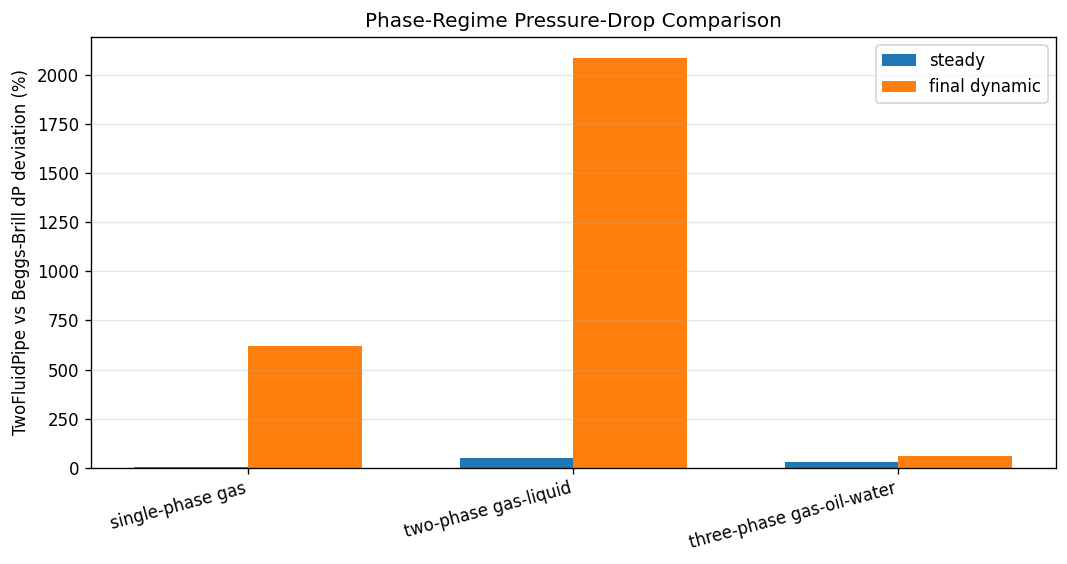

{
  "cases_completed": 3,
  "all_inlet_pressure_residuals_small": true,
  "no_twofluid_boundary_mismatches": true,
  "no_twofluid_pressure_rise": true,
  "all_dynamic_pressure_drops_finite": true,
  "passed": true
}
{
  "transient_structural_checks_passed": true,
  "passed_definition": "The phase-regime verification pass means the one-, two-, and three-phase cases were initialized from specified inlet pressure and flow, advanced dynamically, and kept finite pressure drops, inlet-pressure residuals below 0.05 bar, no boundary mismatch, and no pressure rise. It is not a pressure-drop parity pass.",
  "max_steady_pressure_drop_deviation_pct": 47.00683390669309,
  "max_dynamic_pressure_drop_deviation_pct": 2089.3505473248433,
  "dynamic_pressure_drop_deviation_warning_threshold_pct": 100.0,
  "dynamic_pressure_drop_deviation_warning": true,
  "literature_correlation_reference": "Beggs and Brill (1973), via PipeBeggsAndBrills",
  "interpretation": "The steady single-phase gas comparison is 

,phase_case,specified_inlet_pressure_bara,specified_base_flow_kg_s,specified_ramp_flow_kg_s,inlet_phase_count,inlet_phases,steady_twofluid_pressure_drop_bar,steady_beggs_brill_pressure_drop_bar,steady_pressure_drop_deviation_pct,final_dynamic_twofluid_pressure_drop_bar,final_dynamic_beggs_brill_pressure_drop_bar,final_dynamic_pressure_drop_deviation_pct,final_twofluid_inlet_pressure_residual_bar,final_twofluid_boundary_mismatch,final_twofluid_pressure_rise,final_twofluid_dominant_flow_regime,final_beggs_brill_flow_regime,final_average_holdup_difference
0,single-phase gas,80.0,12.0,18.0,1,GAS,0.5207,0.5483,5.0313,3.4774,0.4823,620.9458,0.0,False,False,SINGLE_PHASE_GAS,SINGLE_PHASE,0.0000
1,two-phase gas-liquid,80.0,12.0,18.0,2,"GAS, OIL",0.3791,0.2579,47.0068,5.4591,0.2493,2089.3505,0.0,False,False,SINGLE_PHASE_LIQUID,TRANSITION,-0.0802
2,three-phase gas-oil-water,80.0,12.0,18.0,3,"GAS, OIL, AQUEOUS",0.3778,0.2963,27.5230,0.4621,0.2868,61.1207,0.0,False,False,SINGLE_PHASE_GAS,TRANSITION,-0.0822


In [ ]:
PHASE_VERIFY_PRESSURE_BARA = 80.0
PHASE_VERIFY_TEMPERATURE_C = 45.0
PHASE_VERIFY_BASE_FLOW_KG_S = 12.0
PHASE_VERIFY_RAMP_FLOW_KG_S = 18.0
PHASE_VERIFY_LENGTH_M = 5000.0
PHASE_VERIFY_DIAMETER_M = 0.30
PHASE_VERIFY_SECTIONS = 12
PHASE_VERIFY_SURFACE_TEMPERATURE_C = 10.0
PHASE_VERIFY_HEAT_TRANSFER_COEFF_W_M2K = 4.0
PHASE_VERIFY_DT_S = 120.0
PHASE_VERIFY_STEPS = 3
phase_verify_terrain = np.zeros(PHASE_VERIFY_SECTIONS)


def create_phase_regime_fluid(case_name, temperature_C=PHASE_VERIFY_TEMPERATURE_C, pressure_bara=PHASE_VERIFY_PRESSURE_BARA):
    if case_name == "single-phase gas":
        fluid = ns.SystemSrkEos(273.15 + temperature_C, pressure_bara)
        composition = [
            ("methane", 94.0),
            ("ethane", 4.0),
            ("nitrogen", 2.0),
        ]
        mixing_rule = "classic"
    elif case_name == "two-phase gas-liquid":
        fluid = ns.SystemSrkEos(273.15 + temperature_C, pressure_bara)
        composition = [
            ("methane", 70.0),
            ("ethane", 7.0),
            ("propane", 6.0),
            ("n-butane", 5.0),
            ("n-pentane", 4.0),
            ("n-hexane", 4.0),
            ("n-heptane", 4.0),
        ]
        mixing_rule = "classic"
    elif case_name == "three-phase gas-oil-water":
        fluid = ns.SystemSrkCPAstatoil(273.15 + temperature_C, pressure_bara)
        composition = [
            ("nitrogen", 1.0),
            ("CO2", 2.5),
            ("methane", 65.0),
            ("ethane", 8.0),
            ("propane", 6.0),
            ("i-butane", 2.0),
            ("n-butane", 3.0),
            ("i-pentane", 2.5),
            ("n-pentane", 3.0),
            ("n-hexane", 2.5),
            ("n-heptane", 2.0),
            ("n-octane", 1.0),
            ("water", 1.5),
        ]
        mixing_rule = 10
    else:
        raise ValueError(f"Unknown phase-regime case: {case_name}")

    for component, amount in composition:
        fluid.addComponent(component, amount)
    fluid.setMixingRule(mixing_rule)
    fluid.setMultiPhaseCheck(True)
    return fluid


def create_phase_regime_stream(case_name, stream_name, flow_kg_s=PHASE_VERIFY_BASE_FLOW_KG_S):
    fluid = create_phase_regime_fluid(case_name)
    stream = ns.Stream(stream_name, fluid)
    stream.setFlowRate(flow_kg_s, "kg/sec")
    stream.setTemperature(PHASE_VERIFY_TEMPERATURE_C, "C")
    stream.setPressure(PHASE_VERIFY_PRESSURE_BARA, "bara")
    stream.run()
    return stream


def stream_phase_names(stream):
    fluid = stream.getFluid()
    names = []
    for phase_index in range(int(fluid.getNumberOfPhases())):
        names.append(str(fluid.getPhase(phase_index).getType()))
    return names


def configure_phase_regime_twofluid(case_name, stream):
    pipe_model = TwoFluidPipe(case_name + " TwoFluidPipe", stream)
    pipe_model.setLength(PHASE_VERIFY_LENGTH_M)
    pipe_model.setDiameter(PHASE_VERIFY_DIAMETER_M)
    pipe_model.setNumberOfSections(PHASE_VERIFY_SECTIONS)
    pipe_model.setRoughness(4.5e-5)
    pipe_model.setElevationProfile(phase_verify_terrain.tolist())
    pipe_model.setSurfaceTemperature(PHASE_VERIFY_SURFACE_TEMPERATURE_C, "C")
    pipe_model.setHeatTransferCoefficient(PHASE_VERIFY_HEAT_TRANSFER_COEFF_W_M2K)
    pipe_model.setThermodynamicUpdateInterval(25)
    pipe_model.setOLGAModelType(TwoFluidPipe.OLGAModelType.SIMPLIFIED)
    pipe_model.setSlugTrackingMode(TwoFluidPipe.SlugTrackingMode.SIMPLIFIED)
    pipe_model.setEnableAdaptiveTimestepping(True)
    pipe_model.setAdaptiveMaxPressureChangeRatio(1.5)
    pipe_model.setTimeIntegrationMethod(TimeMethod.IMEX_PRESSURE_CORRECTION)
    pipe_model.useInletPressureDrivenTransient()
    return pipe_model


def configure_phase_regime_beggs(case_name, stream):
    pipe_model = PipeBeggsAndBrills(case_name + " Beggs-Brill", stream)
    pipe_model.setLength(PHASE_VERIFY_LENGTH_M)
    pipe_model.setDiameter(PHASE_VERIFY_DIAMETER_M)
    pipe_model.setElevation(0.0)
    pipe_model.setPipeWallRoughness(4.5e-5)
    pipe_model.setNumberOfIncrements(PHASE_VERIFY_SECTIONS)
    pipe_model.setConstantSurfaceTemperature(PHASE_VERIFY_SURFACE_TEMPERATURE_C, "C")
    pipe_model.setHeatTransferCoefficient(PHASE_VERIFY_HEAT_TRANSFER_COEFF_W_M2K)
    return pipe_model


def capture_phase_regime_twofluid(pipe_model, case_name, time_s, flow_kg_s):
    profile = profile_dataframe(pipe_model, phase_verify_terrain, PHASE_VERIFY_LENGTH_M)
    return {
        "phase_case": case_name,
        "time_s": float(time_s),
        "time_min": float(time_s / 60.0),
        "feed_flow_kg_s": float(flow_kg_s),
        "twofluid_inlet_pressure_bara": float(profile["pressure_bara"].iloc[0]),
        "twofluid_outlet_pressure_bara": float(pipe_model.getOutletStream().getPressure("bara")),
        "twofluid_pressure_drop_bar": float(pipe_model.getSignedPressureDrop("bar")),
        "twofluid_average_liquid_holdup": float(pipe_model.getAverageLiquidHoldup()),
        "twofluid_liquid_inventory_m3": float(pipe_model.getLiquidInventory("m3")),
        "twofluid_dominant_flow_regime": str(pipe_model.getDominantFlowRegime()),
        "twofluid_inlet_pressure_residual_bar": float(pipe_model.getInletPressureResidual("bar")),
        "twofluid_boundary_mismatch": bool(pipe_model.hasBoundaryConditionPressureMismatch()),
        "twofluid_pressure_rise": bool(pipe_model.hasPressureRiseAcrossPipe()),
        "twofluid_max_abs_gas_velocity_m_s": float(np.abs(profile["gas_velocity_m_s"]).max()),
        "twofluid_max_abs_liquid_velocity_m_s": float(np.abs(profile["liquid_velocity_m_s"]).max()),
        "twofluid_adaptive_dt_factor": float(pipe_model.getAdaptiveDtFactor()),
    }


def capture_phase_regime_beggs(pipe_model, case_name, time_s, flow_kg_s):
    pressure_profile = java_double_array(pipe_model.getPressureProfile())
    liquid_holdup_profile = java_double_array(pipe_model.getLiquidHoldupProfile())
    return {
        "phase_case": case_name,
        "time_s": float(time_s),
        "time_min": float(time_s / 60.0),
        "feed_flow_kg_s": float(flow_kg_s),
        "beggs_brill_inlet_pressure_bara": float(pressure_profile[0]) if len(pressure_profile) else np.nan,
        "beggs_brill_outlet_pressure_bara": float(pipe_model.getOutletStream().getPressure("bara")),
        "beggs_brill_pressure_drop_bar": float(pipe_model.getPressureDrop()),
        "beggs_brill_average_liquid_holdup": float(np.mean(liquid_holdup_profile)) if len(liquid_holdup_profile) else np.nan,
        "beggs_brill_flow_regime": str(pipe_model.getFlowRegimeEnum()),
    }


phase_regime_case_names = [
    "single-phase gas",
    "two-phase gas-liquid",
    "three-phase gas-oil-water",
]
phase_regime_summary_rows = []
phase_regime_dynamic_rows = []

for case_name in phase_regime_case_names:
    inlet_stream = create_phase_regime_stream(case_name, case_name + " feed", PHASE_VERIFY_BASE_FLOW_KG_S)
    beggs_stream = create_phase_regime_stream(case_name, case_name + " Beggs feed", PHASE_VERIFY_BASE_FLOW_KG_S)
    inlet_phases = stream_phase_names(inlet_stream)

    twofluid_pipe = configure_phase_regime_twofluid(case_name, inlet_stream)
    beggs_pipe = configure_phase_regime_beggs(case_name, beggs_stream)

    twofluid_pipe.run()
    beggs_pipe.run()
    beggs_pipe.setCalculateSteadyState(False)

    twofluid_steady = capture_phase_regime_twofluid(twofluid_pipe, case_name, 0.0, PHASE_VERIFY_BASE_FLOW_KG_S)
    beggs_steady = capture_phase_regime_beggs(beggs_pipe, case_name, 0.0, PHASE_VERIFY_BASE_FLOW_KG_S)

    run_id = JavaUUID.randomUUID()
    beggs_run_id = JavaUUID.randomUUID()
    current_flow = PHASE_VERIFY_BASE_FLOW_KG_S
    phase_regime_dynamic_rows.append({**twofluid_steady, **beggs_steady, "stage": "steady seed"})

    for step in range(1, PHASE_VERIFY_STEPS + 1):
        if step == 2:
            current_flow = PHASE_VERIFY_RAMP_FLOW_KG_S
            inlet_stream.setFlowRate(current_flow, "kg/sec")
            inlet_stream.run()
            beggs_stream.setFlowRate(current_flow, "kg/sec")
            beggs_stream.run()

        twofluid_pipe.runTransient(PHASE_VERIFY_DT_S, run_id)
        beggs_pipe.runTransient(PHASE_VERIFY_DT_S, beggs_run_id)
        time_s = step * PHASE_VERIFY_DT_S
        phase_regime_dynamic_rows.append({
            **capture_phase_regime_twofluid(twofluid_pipe, case_name, time_s, current_flow),
            **capture_phase_regime_beggs(beggs_pipe, case_name, time_s, current_flow),
            "stage": "dynamic",
        })

    final_row = phase_regime_dynamic_rows[-1]
    steady_dp_deviation_pct = (
        abs(twofluid_steady["twofluid_pressure_drop_bar"] - beggs_steady["beggs_brill_pressure_drop_bar"])
        / max(abs(beggs_steady["beggs_brill_pressure_drop_bar"]), 1.0e-12)
        * 100.0
    )
    final_dynamic_dp_deviation_pct = (
        abs(final_row["twofluid_pressure_drop_bar"] - final_row["beggs_brill_pressure_drop_bar"])
        / max(abs(final_row["beggs_brill_pressure_drop_bar"]), 1.0e-12)
        * 100.0
    )

    phase_regime_summary_rows.append({
        "phase_case": case_name,
        "specified_inlet_pressure_bara": PHASE_VERIFY_PRESSURE_BARA,
        "specified_base_flow_kg_s": PHASE_VERIFY_BASE_FLOW_KG_S,
        "specified_ramp_flow_kg_s": PHASE_VERIFY_RAMP_FLOW_KG_S,
        "inlet_phase_count": len(inlet_phases),
        "inlet_phases": ", ".join(inlet_phases),
        "steady_twofluid_pressure_drop_bar": twofluid_steady["twofluid_pressure_drop_bar"],
        "steady_beggs_brill_pressure_drop_bar": beggs_steady["beggs_brill_pressure_drop_bar"],
        "steady_pressure_drop_deviation_pct": steady_dp_deviation_pct,
        "final_dynamic_twofluid_pressure_drop_bar": final_row["twofluid_pressure_drop_bar"],
        "final_dynamic_beggs_brill_pressure_drop_bar": final_row["beggs_brill_pressure_drop_bar"],
        "final_dynamic_pressure_drop_deviation_pct": final_dynamic_dp_deviation_pct,
        "final_twofluid_inlet_pressure_residual_bar": final_row["twofluid_inlet_pressure_residual_bar"],
        "final_twofluid_boundary_mismatch": final_row["twofluid_boundary_mismatch"],
        "final_twofluid_pressure_rise": final_row["twofluid_pressure_rise"],
        "final_twofluid_dominant_flow_regime": final_row["twofluid_dominant_flow_regime"],
        "final_beggs_brill_flow_regime": final_row["beggs_brill_flow_regime"],
        "final_average_holdup_difference": final_row["twofluid_average_liquid_holdup"] - final_row["beggs_brill_average_liquid_holdup"],
    })

phase_regime_summary_df = pd.DataFrame(phase_regime_summary_rows)
phase_regime_dynamic_df = pd.DataFrame(phase_regime_dynamic_rows)
phase_regime_summary_df.to_csv(OUTPUT_DIR / "phase_regime_verification_summary.csv", index=False)
phase_regime_dynamic_df.to_csv(OUTPUT_DIR / "phase_regime_verification_dynamic_history.csv", index=False)

phase_regime_checks = {
    "cases_completed": int(len(phase_regime_summary_df)),
    "all_inlet_pressure_residuals_small": bool(
        np.abs(phase_regime_summary_df["final_twofluid_inlet_pressure_residual_bar"]).max() < 0.05
    ),
    "no_twofluid_boundary_mismatches": bool((~phase_regime_summary_df["final_twofluid_boundary_mismatch"]).all()),
    "no_twofluid_pressure_rise": bool((~phase_regime_summary_df["final_twofluid_pressure_rise"]).all()),
    "all_dynamic_pressure_drops_finite": bool(
        np.isfinite(phase_regime_summary_df["final_dynamic_twofluid_pressure_drop_bar"]).all()
        and np.isfinite(phase_regime_summary_df["final_dynamic_beggs_brill_pressure_drop_bar"]).all()
    ),
}
phase_regime_checks["passed"] = bool(all(phase_regime_checks.values()))

phase_steady_deviation = (
    phase_regime_summary_df["steady_pressure_drop_deviation_pct"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
phase_dynamic_deviation = (
    phase_regime_summary_df["final_dynamic_pressure_drop_deviation_pct"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
phase_pressure_drop_warning_threshold_pct = 100.0
max_steady_deviation_pct = float(phase_steady_deviation.max()) if len(phase_steady_deviation) else None
max_dynamic_deviation_pct = float(phase_dynamic_deviation.max()) if len(phase_dynamic_deviation) else None
phase_regime_comparison_checks = {
    "transient_structural_checks_passed": bool(phase_regime_checks["passed"]),
    "passed_definition": (
        "The phase-regime verification pass means the one-, two-, and three-phase cases were initialized from "
        "specified inlet pressure and flow, advanced dynamically, and kept finite pressure drops, inlet-pressure "
        "residuals below 0.05 bar, no boundary mismatch, and no pressure rise. It is not a pressure-drop parity pass."
    ),
    "max_steady_pressure_drop_deviation_pct": max_steady_deviation_pct,
    "max_dynamic_pressure_drop_deviation_pct": max_dynamic_deviation_pct,
    "dynamic_pressure_drop_deviation_warning_threshold_pct": phase_pressure_drop_warning_threshold_pct,
    "dynamic_pressure_drop_deviation_warning": bool(
        max_dynamic_deviation_pct is not None
        and max_dynamic_deviation_pct > phase_pressure_drop_warning_threshold_pct
    ),
    "literature_correlation_reference": "Beggs and Brill (1973), via PipeBeggsAndBrills",
}
phase_regime_comparison_checks["interpretation"] = (
    "The steady single-phase gas comparison is close, while two- and three-phase steady cases differ more because "
    "holdup and combined-liquid handling differ. Dynamic pressure-drop deviations are very large even with inlet "
    "pressure references aligned, so the dynamic result should be treated as a model-form/transient-propagation "
    "diagnostic, not as calibrated agreement with Beggs-Brill."
    if phase_regime_comparison_checks["dynamic_pressure_drop_deviation_warning"]
    else "Dynamic pressure-drop deviations are below the warning threshold."
)

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(phase_regime_summary_df))
width = 0.35
ax.bar(
    x - width / 2,
    phase_regime_summary_df["steady_pressure_drop_deviation_pct"],
    width,
    label="steady",
)
ax.bar(
    x + width / 2,
    phase_regime_summary_df["final_dynamic_pressure_drop_deviation_pct"],
    width,
    label="final dynamic",
)
ax.set_xticks(x)
ax.set_xticklabels(phase_regime_summary_df["phase_case"], rotation=15, ha="right")
ax.set_ylabel("TwoFluidPipe vs Beggs-Brill dP deviation (%)")
ax.set_title("Phase-Regime Pressure-Drop Comparison")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
figure_8 = OUTPUT_DIR / "phase_regime_pressure_drop_comparison.png"
fig.savefig(figure_8, bbox_inches="tight")
plt.show()

results = json.loads(results_path.read_text(encoding="utf-8"))
results["phase_regime_verification"] = {
    "input_basis": {
        "inlet_pressure_bara": PHASE_VERIFY_PRESSURE_BARA,
        "inlet_temperature_C": PHASE_VERIFY_TEMPERATURE_C,
        "base_flow_kg_s": PHASE_VERIFY_BASE_FLOW_KG_S,
        "ramp_flow_kg_s": PHASE_VERIFY_RAMP_FLOW_KG_S,
        "pipe_length_m": PHASE_VERIFY_LENGTH_M,
        "pipe_diameter_m": PHASE_VERIFY_DIAMETER_M,
        "sections": PHASE_VERIFY_SECTIONS,
        "time_step_s": PHASE_VERIFY_DT_S,
        "dynamic_steps": PHASE_VERIFY_STEPS,
        "pressure_reference": "INLET_PRESSURE",
    },
    "literature_reference": "Beggs, H.D. and Brill, J.P. (1973). A Study of Two-Phase Flow in Inclined Pipes. Journal of Petroleum Technology 25(5):607-617.",
    "comparison_scope": (
        "Each phase case is initialized from the specified inlet pressure and mass flow in steady state, "
        "then the initialized state is advanced dynamically through the same flow-step schedule. "
        "Beggs-Brill is the literature-correlation anchor; the three-phase case is compared as a combined-liquid pressure-drop benchmark."
    ),
    "checks": phase_regime_checks,
    "comparison_checks": phase_regime_comparison_checks,
    "summary": phase_regime_summary_df.to_dict(orient="records"),
    "dynamic_history": phase_regime_dynamic_df.to_dict(orient="records"),
}
figure_paths = list(results.get("figures", []))
figure_8_path = str(figure_8.relative_to(PROJECT_ROOT))
if figure_8_path not in figure_paths:
    figure_paths.append(figure_8_path)
results["figures"] = figure_paths
results_path.write_text(json.dumps(results, indent=2), encoding="utf-8")

print(json.dumps(phase_regime_checks, indent=2))
print(json.dumps(phase_regime_comparison_checks, indent=2))
display(phase_regime_summary_df)

## Takeaways

- Thermodynamic coupling is central: each pipe section needs phase properties from a local flash before phase momentum and holdup are meaningful.
- `TwoFluidPipe` exposes the practical result channels needed for multiphase transient screening: pressure, temperature, oil/water/liquid holdup, phase velocities, flow regimes, liquid inventory, and slug statistics.
- Long pipelines should be checked in both steady and dynamic modes. The 20-80 km examples exercise pressure reconstruction, heat transfer, terrain holdup, adaptive time stepping, and explicit transient pressure-reference modes.
- Beggs and Brill is a useful published-correlation benchmark for pressure-drop magnitude, but field data or a high-fidelity transient simulator is still needed for project-grade slugging and dynamic inventory validation.
- Boundary conditions matter. Match the pressure reference before interpreting dynamic pressure-drop deviations, then review profiles and time histories together before using outlet-only metrics for design decisions.